# MDPI Traffic Sign Revision Notebook — Seed 777

This seed-specific Kaggle notebook is part of the reviewer-response revision plan. Seed 42 runs the full protocol and auxiliary analyses; the other seed notebooks generate the additional per-seed outputs required for multi-seed mean ± std tables and figures.

## 0. Run configuration

Recommended stage order under a 12-hour Kaggle GPU limit:

1. `RUN_STAGE = ["train_main"]` — trains CNN, ResNet18, MobileNetV2, and MobileNetV2+CBAM on GTSRB.
2. `RUN_STAGE = ["train_kd"]` — trains a distilled MobileNetV2 student using ResNet18 as teacher.
3. `RUN_STAGE = ["train_ablation"]` — trains the two no-augmentation MobileNetV2 variants.
4. `RUN_STAGE = ["evaluate"]` — clean metrics, bootstrap 95% CIs, robustness, calibration, statistical tests, and efficiency profiling.
5. `RUN_STAGE = ["external"]` — evaluates GTSRB-trained checkpoints on correctly parsed GTSDB cropped signs.
6. `RUN_STAGE = ["xai"]` — generates Grad-CAM examples and heatmap concentration metrics.
7. `RUN_STAGE = ["package"]` — zips the output folder.

The default `RUN_STAGE = ["all"]` performs all stages in one run. If the Kaggle session ends, save `/kaggle/working/revision_outputs_fast128` as a Kaggle Dataset and attach it to the next session through `PREVIOUS_OUTPUTS_INPUT_DIR`.


In [1]:

# ============================================================
# 0. CONFIGURATION: FAST 12-HOUR REVISION PROTOCOL
# ============================================================

import os, json, time, random, math, shutil, glob, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# ---------- USER SETTINGS ----------
# Default: run the complete pipeline directly.
# For staged/resume runs, use one of:
# ["train_main"], ["train_kd"], ["train_ablation"], ["evaluate"], ["external"], ["xai"], ["package"]
RUN_STAGE = ["train_main", "train_kd", "evaluate", "external", "package"]

# Main GTSRB Kaggle dataset:
# https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
GTSRB_ROOT_CANDIDATES = [
    "/kaggle/input/gtsrb-german-traffic-sign",
    "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign",
    "/kaggle/input/german-traffic-sign-recognition-benchmark",
    "/kaggle/input",
]

# Correct external GTSDB Kaggle dataset:
# https://www.kaggle.com/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset
# Important: this is NOT the GTSRB path.
GTSDB_ROOT_CANDIDATES = [
    "/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset",
    "/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test",
    "/kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test",
    "/kaggle/input/german-traffic-sign-detection-gtsdb-dataset",
    "/kaggle/input/gtsdb-german-traffic-sign-detection",
]
EXTERNAL_DATASETS_TO_USE = ["gtsdb"]

def resolve_root(candidates, must_contain_any=None, label="dataset"):
    """Pick the first candidate path that exists and, if requested, contains a marker file."""
    must_contain_any = must_contain_any or []
    for c in candidates:
        p = Path(c)
        if not p.exists():
            continue
        if not must_contain_any:
            print(f"{label} root resolved to: {p}")
            return str(p)
        for marker in must_contain_any:
            if list(p.rglob(marker)):
                print(f"{label} root resolved to: {p} (found {marker})")
                return str(p)
    # Fall back to first candidate; downstream cells will raise a clear error if markers are missing.
    fallback = candidates[0]
    print(f"WARNING: Could not verify {label} root. Falling back to: {fallback}")
    return fallback

GTSRB_ROOT = resolve_root(GTSRB_ROOT_CANDIDATES, must_contain_any=["Train.csv"], label="GTSRB")
GTSDB_ROOT = resolve_root(GTSDB_ROOT_CANDIDATES, must_contain_any=[], label="GTSDB")

# If continuing from a previous Kaggle session:
# 1) Create a Kaggle Dataset from /kaggle/working/revision_outputs_fast128 in the previous session.
# 2) Attach it to this notebook.
# 3) Set PREVIOUS_OUTPUTS_INPUT_DIR to the attached dataset folder containing revision_outputs_fast128.
PREVIOUS_OUTPUTS_INPUT_DIR = ""  # example: "/kaggle/input/traffic-sign-revision-fast128/revision_outputs_fast128"

# Output folder in current session.
OUT_DIR = Path("/kaggle/working/revision_outputs_multiseed")
CHECKPOINT_DIR = OUT_DIR / "checkpoints"
LOG_DIR = OUT_DIR / "logs"
PRED_DIR = OUT_DIR / "predictions"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
STATUS_DIR = OUT_DIR / "status"
for d in [OUT_DIR, CHECKPOINT_DIR, LOG_DIR, PRED_DIR, TABLE_DIR, FIG_DIR, STATUS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---------- FAST RUNTIME SETTINGS ----------
SEED_LIST = [777]
MAX_EPOCHS = 25
PATIENCE = 4
ABLATION_MAX_EPOCHS = 12
ABLATION_PATIENCE = 3

# Knowledge distillation settings
KD_MAX_EPOCHS = 15
KD_PATIENCE = 4
KD_TEACHER_MODEL = "resnet18"
KD_STUDENT_MODEL = "mobilenetv2_kd"
KD_TEMPERATURE = 4.0
KD_ALPHA = 0.35  # CE weight; (1-alpha) is soft teacher KL weight.

# 128x128 is much faster than 224x224 and remains suitable for cropped traffic-sign classification.
IMG_SIZE = 128
CENTER_CROP = 90
BATCH_SIZE = 64
NUM_CLASSES = 43
NUM_WORKERS = 2
PIN_MEMORY = True

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
USE_PRETRAINED = False
USE_AMP = True

# To keep within Kaggle time, you can limit work during trial runs.
DEBUG_SMALL_RUN = False
DEBUG_MAX_BATCHES = 3

# Models in main comparison
MAIN_MODELS = ["cnn", "resnet18", "mobilenetv2", "mobilenetv2_cbam"]

# Distilled model is trained separately but evaluated alongside the main models.
DISTILLED_MODELS = ["mobilenetv2_kd"]
EVAL_MODELS = MAIN_MODELS + DISTILLED_MODELS

# Focused ablation to separate augmentation effects from CBAM effects.
ABLATION_VARIANTS = [
    {"name": "mobilenetv2_noaug_nocbam", "base": "mobilenetv2", "augmentation": False, "cbam": False},
    {"name": "mobilenetv2_noaug_cbam",   "base": "mobilenetv2", "augmentation": False, "cbam": True},
]

ROBUSTNESS_SEVERITIES = [1, 2, 3]
XAI_NUM_SAMPLES = 8
BOOTSTRAP_N = 1000
BOOTSTRAP_SEED = 42

CURRENT_SEED = 777
ENABLE_AUXILIARY_ANALYSES = False
# Auxiliary analyses are intentionally run only in seed 42 to avoid redundant GPU work.
# The other seed notebooks produce the per-seed outputs needed for multi-seed aggregation.
KD_SENSITIVITY_GRID = [
    {"temperature": 2.0, "alpha": 0.35},
    {"temperature": 4.0, "alpha": 0.35},
    {"temperature": 6.0, "alpha": 0.35},
    {"temperature": 4.0, "alpha": 0.50},
    {"temperature": 4.0, "alpha": 0.70},
]
RANDOM_OCCLUSION_REPEATS = 3


print("RUN_STAGE:", RUN_STAGE)
print("Output folder:", OUT_DIR)
print("GTSRB_ROOT:", GTSRB_ROOT)
print("GTSDB_ROOT:", GTSDB_ROOT)
print("Fast settings:", {
    "SEED_LIST": SEED_LIST, "IMG_SIZE": IMG_SIZE, "BATCH_SIZE": BATCH_SIZE,
    "MAX_EPOCHS": MAX_EPOCHS, "PATIENCE": PATIENCE, "USE_AMP": USE_AMP,
    "KD_MAX_EPOCHS": KD_MAX_EPOCHS, "KD_TEMPERATURE": KD_TEMPERATURE, "KD_ALPHA": KD_ALPHA
})


GTSRB root resolved to: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign (found Train.csv)
GTSDB root resolved to: /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset
RUN_STAGE: ['train_main', 'train_kd', 'evaluate', 'external', 'package']
Output folder: /kaggle/working/revision_outputs_multiseed
GTSRB_ROOT: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
GTSDB_ROOT: /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset
Fast settings: {'SEED_LIST': [777], 'IMG_SIZE': 128, 'BATCH_SIZE': 64, 'MAX_EPOCHS': 25, 'PATIENCE': 4, 'USE_AMP': True, 'KD_MAX_EPOCHS': 15, 'KD_TEMPERATURE': 4.0, 'KD_ALPHA': 0.35}


In [2]:

# ============================================================
# 0.1 OPTIONAL: restore outputs from previous Kaggle session
# ============================================================

def restore_previous_outputs(previous_dir: str, out_dir: Path):
    if previous_dir and Path(previous_dir).exists():
        print(f"Restoring previous outputs from: {previous_dir}")
        src = Path(previous_dir)
        # Copy contents into /kaggle/working/revision_outputs without deleting current contents
        for item in src.iterdir():
            dst = out_dir / item.name
            if item.is_dir():
                shutil.copytree(item, dst, dirs_exist_ok=True)
            else:
                shutil.copy2(item, dst)
        print("Previous outputs restored.")
    else:
        print("No previous output directory provided or found. Starting/continuing with current working folder.")

restore_previous_outputs(PREVIOUS_OUTPUTS_INPUT_DIR, OUT_DIR)


No previous output directory provided or found. Starting/continuing with current working folder.


## 1. Imports and utility functions

In [3]:

# ============================================================
# 1. IMPORTS AND UTILITIES
# ============================================================

import numpy as np
import pandas as pd
from PIL import Image, ImageFilter, ImageEnhance, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    classification_report
)
from scipy.stats import wilcoxon

import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Determinism can slow training; still useful for reviewer-grade reproducibility.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def load_json(path, default=None):
    if Path(path).exists():
        with open(path, "r") as f:
            return json.load(f)
    return default

def file_exists(path):
    return Path(path).exists()

def save_fig(path):
    """Save every figure as a publication-ready PDF and display it in the notebook."""
    plt.tight_layout()
    plt.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close()

def update_status(row: dict):
    status_file = STATUS_DIR / "experiment_status.csv"
    df_new = pd.DataFrame([row])
    if status_file.exists():
        df = pd.read_csv(status_file)
        # replace matching stage/model/seed if present
        keys = ["stage", "model", "seed"]
        for k in keys:
            if k not in df.columns: df[k] = ""
        mask = np.ones(len(df), dtype=bool)
        for k in keys:
            mask &= df[k].astype(str).eq(str(row.get(k, "")))
        df = df.loc[~mask]
        df = pd.concat([df, df_new], ignore_index=True)
    else:
        df = df_new
    df.to_csv(status_file, index=False)

def result_already_done(path):
    if Path(path).exists():
        print(f"Skipping because result exists: {path}")
        return True
    return False


DEVICE: cuda
GPU: Tesla T4


## 2. Locate and load GTSRB metadata

The notebook tries to detect `Train.csv` and optional `Test.csv`. If your Kaggle dataset uses a different folder structure, update `GTSRB_ROOT`.


In [4]:

# ============================================================
# 2. DATASET DISCOVERY
# ============================================================

def find_file(root, filename):
    matches = list(Path(root).rglob(filename))
    if not matches:
        return None
    return str(matches[0])

train_csv_path = find_file(GTSRB_ROOT, "Train.csv")
test_csv_path = find_file(GTSRB_ROOT, "Test.csv")
print("Train.csv:", train_csv_path)
print("Test.csv:", test_csv_path)

if train_csv_path is None:
    raise FileNotFoundError("Could not find Train.csv. Please set GTSRB_ROOT correctly.")

train_df_raw = pd.read_csv(train_csv_path)
print(train_df_raw.head())
print(train_df_raw.columns)

# Expected columns often include: Width, Height, Roi.X1, Roi.Y1, Roi.X2, Roi.Y2, ClassId, Path
# Create absolute image path
train_root = Path(train_csv_path).parent
if "Path" not in train_df_raw.columns or "ClassId" not in train_df_raw.columns:
    raise ValueError("Train.csv must contain Path and ClassId columns.")

train_df_raw["abs_path"] = train_df_raw["Path"].apply(lambda p: str(train_root / p))

# Optional small debug
if DEBUG_SMALL_RUN:
    train_df_raw = train_df_raw.groupby("ClassId", group_keys=False).apply(lambda x: x.sample(min(len(x), 20), random_state=42)).reset_index(drop=True)

print("Total training images available:", len(train_df_raw))
print("Classes:", sorted(train_df_raw["ClassId"].unique())[:5], "...", len(train_df_raw["ClassId"].unique()))


Train.csv: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train.csv
Test.csv: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  
Index(['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId',
       'Path'],
      dtype='object')
Total training images available: 39209
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] ... 43


## 3. Stratified split and dataset tables

The same split is saved and reused in all later sessions. This prevents accidental changes across sessions.


Saved split: /kaggle/working/revision_outputs_multiseed/tables/table_dataset_split_assignments.csv
split
train    31367
val       3921
test      3921
Name: count, dtype: int64


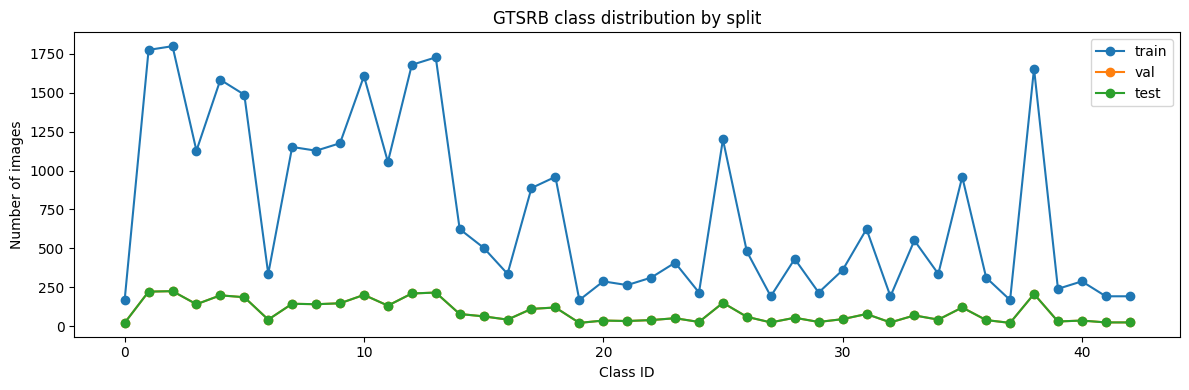

In [5]:

# ============================================================
# 3. SPLIT CREATION OR REUSE
# ============================================================

split_file = TABLE_DIR / "table_dataset_split_assignments.csv"

if split_file.exists():
    split_df = pd.read_csv(split_file)
    print("Loaded existing split:", split_file)
else:
    # 80/10/10 stratified split
    df = train_df_raw.copy()
    train_part, temp_part = train_test_split(
        df, test_size=0.20, random_state=42, stratify=df["ClassId"]
    )
    val_part, test_part = train_test_split(
        temp_part, test_size=0.50, random_state=42, stratify=temp_part["ClassId"]
    )
    train_part = train_part.copy(); train_part["split"] = "train"
    val_part = val_part.copy(); val_part["split"] = "val"
    test_part = test_part.copy(); test_part["split"] = "test"
    split_df = pd.concat([train_part, val_part, test_part], ignore_index=True)
    split_df.to_csv(split_file, index=False)
    print("Saved split:", split_file)

print(split_df["split"].value_counts())

# Class distribution table
dist = split_df.groupby(["split", "ClassId"]).size().reset_index(name="count")
dist.to_csv(TABLE_DIR / "table_class_distribution_by_split.csv", index=False)

# Plot class distribution
plt.figure(figsize=(12, 4))
for split_name in ["train", "val", "test"]:
    counts = split_df[split_df["split"] == split_name]["ClassId"].value_counts().sort_index()
    plt.plot(counts.index, counts.values, marker="o", label=split_name)
plt.xlabel("Class ID")
plt.ylabel("Number of images")
plt.title("GTSRB class distribution by split")
plt.legend()
save_fig(FIG_DIR / "fig_class_distribution_by_split.pdf")


## 4. Dataset class and transforms

Two training transforms are defined:
- no augmentation
- augmentation

Horizontal flipping is intentionally not used by default because it may change the meaning of directional signs.


In [6]:

# ============================================================
# 4. DATASETS AND TRANSFORMS
# ============================================================

train_transform_noaug = transforms.Compose([
    transforms.CenterCrop(CENTER_CROP),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_transform_aug = transforms.Compose([
    transforms.CenterCrop(CENTER_CROP),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.CenterCrop(CENTER_CROP),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class GTSRBDataset(Dataset):
    def __init__(self, df, transform=None, corruption=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.corruption = corruption

    def __len__(self):
        return len(self.df)

    def _apply_corruption(self, img):
        if self.corruption is None:
            return img
        ctype = self.corruption.get("type")
        severity = self.corruption.get("severity", 0)

        if ctype == "blur":
            radius_map = {1: 1, 2: 2, 3: 3}
            return img.filter(ImageFilter.GaussianBlur(radius=radius_map[severity]))

        if ctype == "occlusion":
            # occlude approximately 10%, 20%, 30% of image area with a central black rectangle
            frac_map = {1: 0.10, 2: 0.20, 3: 0.30}
            frac = frac_map[severity]
            w, h = img.size
            side = int(math.sqrt(frac) * min(w, h))
            x1 = (w - side) // 2
            y1 = (h - side) // 2
            img2 = img.copy()
            draw = ImageDraw.Draw(img2)
            draw.rectangle([x1, y1, x1 + side, y1 + side], fill=(0, 0, 0))
            return img2

        if ctype == "low_light":
            factor_map = {1: 0.75, 2: 0.50, 3: 0.25}
            return ImageEnhance.Brightness(img).enhance(factor_map[severity])

        if ctype == "gaussian_noise":
            sigma_map = {1: 0.03, 2: 0.06, 3: 0.10}
            arr = np.asarray(img).astype(np.float32) / 255.0
            noise = np.random.normal(0, sigma_map[severity], arr.shape)
            arr = np.clip(arr + noise, 0, 1)
            return Image.fromarray((arr * 255).astype(np.uint8))

        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["abs_path"]).convert("RGB")
        img = self._apply_corruption(img)
        if self.transform:
            img = self.transform(img)
        label = int(row["ClassId"])
        return img, label, row["abs_path"]

def make_loader(split_name, transform, batch_size=BATCH_SIZE, shuffle=False, corruption=None):
    df = split_df[split_df["split"] == split_name].copy()
    ds = GTSRBDataset(df, transform=transform, corruption=corruption)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

def get_train_val_loaders(use_augmentation=True):
    train_tf = train_transform_aug if use_augmentation else train_transform_noaug
    train_loader = make_loader("train", train_tf, shuffle=True)
    val_loader = make_loader("val", eval_transform, shuffle=False)
    return train_loader, val_loader

test_loader_clean = make_loader("test", eval_transform, shuffle=False)
print("Test batches:", len(test_loader_clean))


Test batches: 62


## 5. Model definitions

This section defines the baseline CNN, MobileNetV2+CBAM, and model factory.


In [7]:

# ============================================================
# 5. MODEL DEFINITIONS
# ============================================================

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Adaptive pooling keeps the baseline CNN compatible with IMG_SIZE=96 and IMG_SIZE=224.
            nn.AdaptiveAvgPool2d((6, 6)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 6 * 6, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False)
        )
    def forward(self, x):
        avg = F.adaptive_avg_pool2d(x, 1)
        mx = F.adaptive_max_pool2d(x, 1)
        return torch.sigmoid(self.mlp(avg) + self.mlp(mx))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        return torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)
    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

class MobileNetV2CBAM(nn.Module):
    def __init__(self, num_classes=43, pretrained=False):
        super().__init__()
        weights = models.MobileNet_V2_Weights.DEFAULT if pretrained else None
        base = models.mobilenet_v2(weights=weights)
        self.features = base.features
        self.cbam = CBAM(channels=1280, reduction=16, kernel_size=7)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(1280, num_classes)
    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)

def get_model(model_name, num_classes=NUM_CLASSES, pretrained=USE_PRETRAINED):
    if model_name == "cnn":
        return BaselineCNN(num_classes)
    elif model_name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model
    elif model_name in ["mobilenetv2", "mobilenetv2_kd"]:
        # mobilenetv2_kd has the same architecture as MobileNetV2;
        # it differs only by the knowledge-distillation training objective.
        weights = models.MobileNet_V2_Weights.DEFAULT if pretrained else None
        model = models.mobilenet_v2(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        return model
    elif model_name == "mobilenetv2_cbam":
        return MobileNetV2CBAM(num_classes=num_classes, pretrained=pretrained)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def model_size_mb(model):
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    return (param_size + buffer_size) / (1024 ** 2)

# Save model complexity table
rows = []
for m in EVAL_MODELS:
    model = get_model(m)
    total, trainable = count_parameters(model)
    rows.append({
        "model": m,
        "parameters": total,
        "trainable_parameters": trainable,
        "model_size_mb": model_size_mb(model)
    })
pd.DataFrame(rows).to_csv(TABLE_DIR / "table_model_complexity.csv", index=False)
pd.DataFrame(rows)


,model,parameters,trainable_parameters,model_size_mb
0,cnn,319979,319979,1.220623
1,resnet18,11198571,11198571,42.755932
2,mobilenetv2,2278955,2278955,8.824047
3,mobilenetv2_cbam,2483853,2483853,9.605671
4,mobilenetv2_kd,2278955,2278955,8.824047


## 6. Training and checkpoint functions

This block supports resume-from-last-checkpoint. If Kaggle stops, the next session can continue from the last saved epoch.


In [8]:

# ============================================================
# 6. TRAINING FUNCTIONS WITH CHECKPOINT RESUME
# ============================================================

def compute_metrics_from_logits(logits, labels):
    preds = logits.argmax(axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    wp, wr, wf1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "weighted_f1": wf1
    }

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    all_logits, all_labels, all_paths = [], [], []
    total_loss, n = 0.0, 0
    criterion = nn.CrossEntropyLoss()
    amp_enabled = bool(USE_AMP and DEVICE == "cuda")
    for b, (x, y, paths) in enumerate(loader):
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=amp_enabled):
            logits = model(x)
            loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        n += x.size(0)
        all_logits.append(logits.detach().cpu())
        all_labels.append(y.detach().cpu())
        all_paths.extend(list(paths))
        if DEBUG_SMALL_RUN and b >= DEBUG_MAX_BATCHES:
            break
    logits_np = torch.cat(all_logits).numpy()
    labels_np = torch.cat(all_labels).numpy()
    metrics = compute_metrics_from_logits(logits_np, labels_np)
    metrics["loss"] = total_loss / max(n, 1)
    return metrics, logits_np, labels_np, all_paths

def train_one_model(model_name, seed, use_augmentation=True, max_epochs=MAX_EPOCHS, patience=PATIENCE, run_label="main"):
    set_seed(seed)
    model = get_model(model_name).to(DEVICE)
    train_loader, val_loader = get_train_val_loaders(use_augmentation=use_augmentation)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=3, factor=0.5
    )
    criterion = nn.CrossEntropyLoss()
    amp_enabled = bool(USE_AMP and DEVICE == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

    ckpt_last = CHECKPOINT_DIR / f"{run_label}_{model_name}_seed{seed}_last.pth"
    ckpt_best = CHECKPOINT_DIR / f"{run_label}_{model_name}_seed{seed}_best.pth"
    log_file = LOG_DIR / f"training_log_{run_label}_{model_name}_seed{seed}.csv"

    start_epoch, best_val_f1, best_epoch, history = 0, -1, -1, []
    epochs_without_improve = 0

    if ckpt_last.exists():
        ckpt = torch.load(ckpt_last, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        try:
            scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        except Exception:
            pass
        try:
            scaler.load_state_dict(ckpt.get("scaler_state_dict", {}))
        except Exception:
            pass
        start_epoch = ckpt["epoch"] + 1
        best_val_f1 = ckpt.get("best_val_f1", -1)
        best_epoch = ckpt.get("best_epoch", -1)
        history = ckpt.get("history", [])
        epochs_without_improve = ckpt.get("epochs_without_improve", 0)
        print(f"Resuming {run_label}/{model_name}/seed{seed} from epoch {start_epoch}")

    for epoch in range(start_epoch, max_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        t0 = time.time()

        for b, (x, y, _) in enumerate(train_loader):
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=amp_enabled):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * x.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += x.size(0)
            if DEBUG_SMALL_RUN and b >= DEBUG_MAX_BATCHES:
                break

        train_loss /= max(total, 1)
        train_acc = correct / max(total, 1)

        val_metrics, _, _, _ = evaluate_model(model, val_loader)
        scheduler.step(val_metrics["macro_f1"])

        epoch_time = time.time() - t0
        row = {
            "run_label": run_label,
            "model": model_name,
            "seed": seed,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_sec": epoch_time,
        }
        history.append(row)
        pd.DataFrame(history).to_csv(log_file, index=False)

        improved = val_metrics["macro_f1"] > best_val_f1
        if improved:
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            epochs_without_improve = 0
        else:
            epochs_without_improve += 1

        ckpt = {
            "run_label": run_label,
            "model_name": model_name,
            "seed": seed,
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_val_f1": best_val_f1,
            "best_epoch": best_epoch,
            "history": history,
            "epochs_without_improve": epochs_without_improve,
            "use_augmentation": use_augmentation,
        }
        torch.save(ckpt, ckpt_last)
        if improved:
            torch.save(ckpt, ckpt_best)

        print(f"[{run_label}] {model_name} seed={seed} epoch={epoch:02d} "
              f"train_acc={train_acc:.4f} val_f1={val_metrics['macro_f1']:.4f} "
              f"best={best_val_f1:.4f} no_improve={epochs_without_improve}")

        update_status({
            "stage": "training",
            "run_label": run_label,
            "model": model_name,
            "seed": seed,
            "status": "running",
            "last_epoch": epoch,
            "best_epoch": best_epoch,
            "best_val_f1": best_val_f1,
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
        })

        if epochs_without_improve >= patience:
            print(f"Early stopping: {model_name} seed={seed} at epoch {epoch}")
            break

    update_status({
        "stage": "training",
        "run_label": run_label,
        "model": model_name,
        "seed": seed,
        "status": "completed",
        "last_epoch": history[-1]["epoch"] if history else None,
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
    })

def load_best_model(model_name, seed, run_label="main"):
    model = get_model(model_name).to(DEVICE)
    ckpt_best = CHECKPOINT_DIR / f"{run_label}_{model_name}_seed{seed}_best.pth"
    if not ckpt_best.exists():
        raise FileNotFoundError(f"Missing checkpoint: {ckpt_best}")
    ckpt = torch.load(ckpt_best, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, ckpt


## 7. Run main training

This is the longest part. For a 12-hour Kaggle session, start with this stage first. If interrupted, rerun the notebook; it will resume from the last checkpoint.


In [9]:

# ============================================================
# 7. MAIN TRAINING
# ============================================================

if any(stage in ["train_main", "all"] for stage in RUN_STAGE):
    for seed in SEED_LIST:
        for model_name in MAIN_MODELS:
            final_marker = STATUS_DIR / f"done_training_main_{model_name}_seed{seed}.txt"
            
            if final_marker.exists():
                print(f"Already completed training: {model_name} seed={seed}")
                continue

            train_one_model(
                model_name,
                seed,
                use_augmentation=True,
                run_label="main"
            )

            final_marker.write_text("done")


[main] cnn seed=777 epoch=00 train_acc=0.1539 val_f1=0.1277 best=0.1277 no_improve=0
[main] cnn seed=777 epoch=01 train_acc=0.2910 val_f1=0.2182 best=0.2182 no_improve=0
[main] cnn seed=777 epoch=02 train_acc=0.3655 val_f1=0.2903 best=0.2903 no_improve=0
[main] cnn seed=777 epoch=03 train_acc=0.4125 val_f1=0.3748 best=0.3748 no_improve=0
[main] cnn seed=777 epoch=04 train_acc=0.4437 val_f1=0.4210 best=0.4210 no_improve=0
[main] cnn seed=777 epoch=05 train_acc=0.4744 val_f1=0.4740 best=0.4740 no_improve=0
[main] cnn seed=777 epoch=06 train_acc=0.4948 val_f1=0.5052 best=0.5052 no_improve=0
[main] cnn seed=777 epoch=07 train_acc=0.5217 val_f1=0.5579 best=0.5579 no_improve=0
[main] cnn seed=777 epoch=08 train_acc=0.5412 val_f1=0.5678 best=0.5678 no_improve=0
[main] cnn seed=777 epoch=09 train_acc=0.5565 val_f1=0.6200 best=0.6200 no_improve=0
[main] cnn seed=777 epoch=10 train_acc=0.5707 val_f1=0.6355 best=0.6355 no_improve=0
[main] cnn seed=777 epoch=11 train_acc=0.5899 val_f1=0.6618 best=

In [10]:

# ============================================================
# 7B. KNOWLEDGE DISTILLATION: ResNet18 TEACHER -> MobileNetV2 STUDENT
# ============================================================

def distillation_loss(student_logits, teacher_logits, labels, temperature=KD_TEMPERATURE, alpha=KD_ALPHA):
    """
    alpha * CrossEntropy(hard labels) + (1-alpha) * T^2 * KL(student_T || teacher_T)
    This directly addresses the reviewer suggestion to include knowledge distillation.
    """
    ce = F.cross_entropy(student_logits, labels)
    kd = F.kl_div(
        F.log_softmax(student_logits / temperature, dim=1),
        F.softmax(teacher_logits / temperature, dim=1),
        reduction="batchmean"
    ) * (temperature ** 2)
    return alpha * ce + (1.0 - alpha) * kd, ce.detach(), kd.detach()

def train_kd_student(seed, max_epochs=KD_MAX_EPOCHS, patience=KD_PATIENCE):
    set_seed(seed)

    # Teacher: best ResNet18 checkpoint from train_main.
    teacher, teacher_ckpt = load_best_model(KD_TEACHER_MODEL, seed, run_label="main")
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False

    # Student: MobileNetV2 architecture trained with KD objective.
    student = get_model(KD_STUDENT_MODEL).to(DEVICE)
    train_loader, val_loader = get_train_val_loaders(use_augmentation=True)

    optimizer = torch.optim.AdamW(student.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5)
    amp_enabled = bool(USE_AMP and DEVICE == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

    ckpt_last = CHECKPOINT_DIR / f"main_{KD_STUDENT_MODEL}_seed{seed}_last.pth"
    ckpt_best = CHECKPOINT_DIR / f"main_{KD_STUDENT_MODEL}_seed{seed}_best.pth"
    log_file = LOG_DIR / f"training_log_main_{KD_STUDENT_MODEL}_seed{seed}.csv"

    start_epoch, best_val_f1, best_epoch, history = 0, -1, -1, []
    epochs_without_improve = 0

    if ckpt_last.exists():
        ckpt = torch.load(ckpt_last, map_location=DEVICE)
        student.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        try:
            scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        except Exception:
            pass
        try:
            scaler.load_state_dict(ckpt.get("scaler_state_dict", {}))
        except Exception:
            pass
        start_epoch = ckpt["epoch"] + 1
        best_val_f1 = ckpt.get("best_val_f1", -1)
        best_epoch = ckpt.get("best_epoch", -1)
        history = ckpt.get("history", [])
        epochs_without_improve = ckpt.get("epochs_without_improve", 0)
        print(f"Resuming KD student seed{seed} from epoch {start_epoch}")

    for epoch in range(start_epoch, max_epochs):
        student.train()
        train_loss, train_ce, train_kd, correct, total = 0.0, 0.0, 0.0, 0, 0
        t0 = time.time()

        for b, (x, y, _) in enumerate(train_loader):
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=amp_enabled):
                    teacher_logits = teacher(x)

            with torch.cuda.amp.autocast(enabled=amp_enabled):
                student_logits = student(x)
                loss, ce_part, kd_part = distillation_loss(student_logits, teacher_logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * x.size(0)
            train_ce += float(ce_part) * x.size(0)
            train_kd += float(kd_part) * x.size(0)
            correct += (student_logits.argmax(dim=1) == y).sum().item()
            total += x.size(0)

            if DEBUG_SMALL_RUN and b >= DEBUG_MAX_BATCHES:
                break

        train_loss /= max(total, 1)
        train_ce /= max(total, 1)
        train_kd /= max(total, 1)
        train_acc = correct / max(total, 1)

        val_metrics, _, _, _ = evaluate_model(student, val_loader)
        scheduler.step(val_metrics["macro_f1"])

        epoch_time = time.time() - t0
        row = {
            "run_label": "main",
            "model": KD_STUDENT_MODEL,
            "teacher_model": KD_TEACHER_MODEL,
            "seed": seed,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_ce_loss": train_ce,
            "train_kd_loss": train_kd,
            "train_accuracy": train_acc,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_sec": epoch_time,
            "kd_temperature": KD_TEMPERATURE,
            "kd_alpha": KD_ALPHA,
        }
        history.append(row)
        pd.DataFrame(history).to_csv(log_file, index=False)

        improved = val_metrics["macro_f1"] > best_val_f1
        if improved:
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            epochs_without_improve = 0
        else:
            epochs_without_improve += 1

        ckpt = {
            "run_label": "main",
            "model_name": KD_STUDENT_MODEL,
            "teacher_model": KD_TEACHER_MODEL,
            "seed": seed,
            "epoch": epoch,
            "model_state_dict": student.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_val_f1": best_val_f1,
            "best_epoch": best_epoch,
            "history": history,
            "epochs_without_improve": epochs_without_improve,
            "use_augmentation": True,
            "knowledge_distillation": True,
            "kd_temperature": KD_TEMPERATURE,
            "kd_alpha": KD_ALPHA,
        }
        torch.save(ckpt, ckpt_last)
        if improved:
            torch.save(ckpt, ckpt_best)

        print(f"[KD] {KD_STUDENT_MODEL} seed={seed} epoch={epoch:02d} "
              f"train_acc={train_acc:.4f} val_f1={val_metrics['macro_f1']:.4f} "
              f"best={best_val_f1:.4f} no_improve={epochs_without_improve}")

        update_status({
            "stage": "knowledge_distillation",
            "model": KD_STUDENT_MODEL,
            "teacher_model": KD_TEACHER_MODEL,
            "seed": seed,
            "status": "running",
            "last_epoch": epoch,
            "best_epoch": best_epoch,
            "best_val_f1": best_val_f1,
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
        })

        if epochs_without_improve >= patience:
            print(f"Early stopping KD student seed={seed} at epoch {epoch}")
            break

    update_status({
        "stage": "knowledge_distillation",
        "model": KD_STUDENT_MODEL,
        "teacher_model": KD_TEACHER_MODEL,
        "seed": seed,
        "status": "completed",
        "last_epoch": history[-1]["epoch"] if history else None,
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
    })

if any(stage in ["train_kd", "all"] for stage in RUN_STAGE):
    for seed in SEED_LIST:
        final_marker = STATUS_DIR / f"done_training_main_{KD_STUDENT_MODEL}_seed{seed}.txt"
        if final_marker.exists():
            print(f"Already completed KD training: {KD_STUDENT_MODEL} seed={seed}")
            continue
        try:
            train_kd_student(seed)
            final_marker.write_text("done")
        except FileNotFoundError as e:
            print("Cannot train KD student until teacher checkpoint exists:", e)
            print("Run RUN_STAGE = ['train_main'] first, then rerun RUN_STAGE = ['train_kd'].")


[KD] mobilenetv2_kd seed=777 epoch=00 train_acc=0.2346 val_f1=0.2070 best=0.2070 no_improve=0
[KD] mobilenetv2_kd seed=777 epoch=01 train_acc=0.5396 val_f1=0.5675 best=0.5675 no_improve=0
[KD] mobilenetv2_kd seed=777 epoch=02 train_acc=0.7474 val_f1=0.7509 best=0.7509 no_improve=0
[KD] mobilenetv2_kd seed=777 epoch=03 train_acc=0.8442 val_f1=0.8703 best=0.8703 no_improve=0
[KD] mobilenetv2_kd seed=777 epoch=04 train_acc=0.8899 val_f1=0.9124 best=0.9124 no_improve=0
[KD] mobilenetv2_kd seed=777 epoch=05 train_acc=0.9185 val_f1=0.9443 best=0.9443 no_improve=0
[KD] mobilenetv2_kd seed=777 epoch=06 train_acc=0.9337 val_f1=0.9526 best=0.9526 no_improve=0
[KD] mobilenetv2_kd seed=777 epoch=07 train_acc=0.9439 val_f1=0.9605 best=0.9605 no_improve=0
[KD] mobilenetv2_kd seed=777 epoch=08 train_acc=0.9515 val_f1=0.9726 best=0.9726 no_improve=0
[KD] mobilenetv2_kd seed=777 epoch=09 train_acc=0.9528 val_f1=0.9721 best=0.9726 no_improve=1
[KD] mobilenetv2_kd seed=777 epoch=10 train_acc=0.9587 val_f

## 8. Run MobileNetV2 augmentation/CBAM ablation training

This section trains four MobileNetV2 variants. It directly answers whether gains come from CBAM or augmentation.


In [11]:

# ============================================================
# 8. ABLATION TRAINING
# ============================================================

if any(stage in ["train_ablation", "all"] for stage in RUN_STAGE):

    print("Starting ablation training...")

    for seed in SEED_LIST:

        print(f"Running seed: {seed}")

        for variant in ABLATION_VARIANTS:

            variant_name = variant["name"]

            model_name = (
                "mobilenetv2_cbam"
                if variant["cbam"]
                else "mobilenetv2"
            )

            use_aug = variant["augmentation"]

            final_marker = (
                STATUS_DIR
                / f"done_training_ablation_{variant_name}_seed{seed}.txt"
            )

            # ====================================================
            # FIX:
            # Debug marker status
            # ====================================================

            print(f"Checking marker: {final_marker}")

            if final_marker.exists():

                print(
                    f"Already completed ablation training: "
                    f"{variant_name} seed={seed}"
                )

                continue

            print(
                f"START TRAINING -> "
                f"variant={variant_name}, "
                f"seed={seed}"
            )

            train_one_model(
                model_name,
                seed,
                use_augmentation=use_aug,
                max_epochs=ABLATION_MAX_EPOCHS,
                patience=ABLATION_PATIENCE,
                run_label=f"ablation_{variant_name}"
            )

            print(
                f"END TRAINING -> "
                f"variant={variant_name}, "
                f"seed={seed}"
            )

            final_marker.write_text("done")

            print(f"Saved marker: {final_marker}")


## 9. Clean evaluation and predictions

This saves predictions and clean metrics for every model/seed.


,run_label,model,seed,best_epoch,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,loss
0,main,cnn,777,24,0.837541,0.870435,0.817624,0.835046,0.837106,0.508378
1,main,resnet18,777,20,0.991329,0.993520,0.990604,0.991744,0.991359,0.034806
2,main,mobilenetv2,777,6,0.956389,0.955966,0.948895,0.949682,0.956171,0.143060
3,main,mobilenetv2_cbam,777,14,0.982657,0.984724,0.977176,0.980413,0.982602,0.053749
4,main,mobilenetv2_kd,777,14,0.980107,0.984770,0.970746,0.976837,0.980088,0.078790


accuracy     macro_precision     macro_recall      macro_f1  \
                      mean std            mean std         mean std      mean   
model                                                                           
cnn               0.837541 NaN        0.870435 NaN     0.817624 NaN  0.835046   
mobilenetv2       0.956389 NaN        0.955966 NaN     0.948895 NaN  0.949682   
mobilenetv2_cbam  0.982657 NaN        0.984724 NaN     0.977176 NaN  0.980413   
mobilenetv2_kd    0.980107 NaN        0.984770 NaN     0.970746 NaN  0.976837   
resnet18          0.991329 NaN        0.993520 NaN     0.990604 NaN  0.991744   

                     weighted_f1      
                 std        mean std  
model                                 
cnn              NaN    0.837106 NaN  
mobilenetv2      NaN    0.956171 NaN  
mobilenetv2_cbam NaN    0.982602 NaN  
mobilenetv2_kd   NaN    0.980088 NaN  
resnet18         NaN    0.991359 NaN

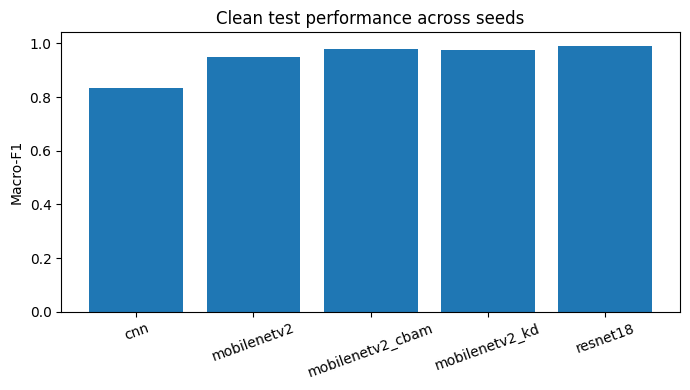

In [12]:

# ============================================================
# 9. CLEAN EVALUATION
# ============================================================

def evaluate_and_save_clean(model_name, seed, run_label="main", output_name=None):
    if output_name is None:
        output_name = f"{run_label}_{model_name}_seed{seed}"
    metrics_file = TABLE_DIR / f"clean_metrics_{output_name}.csv"
    pred_file = PRED_DIR / f"predictions_clean_{output_name}.csv"
    if metrics_file.exists() and pred_file.exists():
        return pd.read_csv(metrics_file).iloc[0].to_dict()

    model, ckpt = load_best_model(model_name, seed, run_label=run_label)
    metrics, logits, labels, paths = evaluate_model(model, test_loader_clean)
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    preds = probs.argmax(axis=1)
    confs = probs.max(axis=1)

    pred_df = pd.DataFrame({
        "path": paths,
        "true": labels,
        "pred": preds,
        "confidence": confs
    })
    for c in range(NUM_CLASSES):
        pred_df[f"prob_{c}"] = probs[:, c]
    pred_df.to_csv(pred_file, index=False)

    row = {
        "run_label": run_label,
        "model": model_name,
        "seed": seed,
        "best_epoch": ckpt.get("best_epoch", None),
        **metrics
    }
    pd.DataFrame([row]).to_csv(metrics_file, index=False)
    return row

if any(stage  in ["evaluate", "all"] for stage in RUN_STAGE ):
    rows = []
    for seed in SEED_LIST:
        for model_name in EVAL_MODELS:
            try:
                rows.append(evaluate_and_save_clean(model_name, seed, "main"))
            except FileNotFoundError as e:
                print("Missing checkpoint; skipping:", e)

    if rows:
        clean_df = pd.DataFrame(rows)
        clean_df.to_csv(TABLE_DIR / "table_clean_performance_per_seed.csv", index=False)
        summary = clean_df.groupby("model")[["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]].agg(["mean", "std"])
        summary.to_csv(TABLE_DIR / "table_clean_performance_mean_std.csv")
        display(clean_df)
        display(summary)

        # Figure: macro F1 mean/std
        plot_df = clean_df.groupby("model")["macro_f1"].agg(["mean", "std"]).reset_index()
        plt.figure(figsize=(7, 4))
        plt.bar(plot_df["model"], plot_df["mean"], yerr=plot_df["std"], capsize=4)
        plt.ylabel("Macro-F1")
        plt.title("Clean test performance across seeds")
        plt.xticks(rotation=20)
        save_fig(FIG_DIR / "fig_clean_macro_f1_mean_std.pdf")


In [13]:

# ============================================================
# 9.1 BOOTSTRAP 95% CONFIDENCE INTERVALS FOR SINGLE-SEED PROTOCOL
# ============================================================

from sklearn.metrics import f1_score, accuracy_score

def bootstrap_ci_from_predictions(y_true, y_pred, n_boot=BOOTSTRAP_N, seed=BOOTSTRAP_SEED):
    """Bootstrap over test samples to estimate 95% CIs for accuracy and macro-F1."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    acc_vals, f1_vals = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        acc_vals.append(accuracy_score(y_true[idx], y_pred[idx]))
        f1_vals.append(f1_score(y_true[idx], y_pred[idx], average="macro", zero_division=0))
    return {
        "accuracy_ci_low": float(np.percentile(acc_vals, 2.5)),
        "accuracy_ci_high": float(np.percentile(acc_vals, 97.5)),
        "macro_f1_ci_low": float(np.percentile(f1_vals, 2.5)),
        "macro_f1_ci_high": float(np.percentile(f1_vals, 97.5)),
        "bootstrap_n": n_boot,
    }

if any(stage in ["evaluate", "all"] for stage in RUN_STAGE):
    rows = []
    for seed in SEED_LIST:
        for model_name in EVAL_MODELS:
            pred_file = PRED_DIR / f"predictions_clean_main_{model_name}_seed{seed}.csv"
            if not pred_file.exists():
                continue
            dfp = pd.read_csv(pred_file)
            ci = bootstrap_ci_from_predictions(dfp["true"].values, dfp["pred"].values)
            rows.append({"model": model_name, "seed": seed, **ci})
    if rows:
        boot_df = pd.DataFrame(rows)
        boot_df.to_csv(TABLE_DIR / "table_bootstrap_ci_clean.csv", index=False)
        display(boot_df)


,model,seed,accuracy_ci_low,accuracy_ci_high,macro_f1_ci_low,macro_f1_ci_high,bootstrap_n
0,cnn,777,0.825803,0.850038,0.818787,0.848432,1000
1,resnet18,777,0.988268,0.994134,0.988198,0.994692,1000
2,mobilenetv2,777,0.950261,0.963275,0.939351,0.958395,1000
3,mobilenetv2_cbam,777,0.978322,0.986738,0.974078,0.985777,1000
4,mobilenetv2_kd,777,0.975765,0.984188,0.970131,0.982687,1000


## 10. Severity-wise robustness evaluation

This evaluates each best checkpoint under blur, occlusion, low light, and Gaussian noise severity levels.


model      corruption severity  accuracy      macro_f1    
                                      mean std      mean std
0   cnn            blur        1  0.763071 NaN  0.747210 NaN
1   cnn            blur        2  0.560826 NaN  0.502237 NaN
2   cnn            blur        3  0.413160 NaN  0.329352 NaN
3   cnn  gaussian_noise        1  0.805407 NaN  0.803882 NaN
4   cnn  gaussian_noise        2  0.711043 NaN  0.702393 NaN

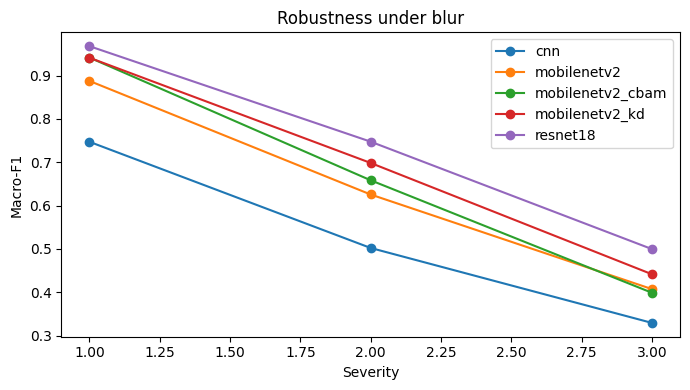

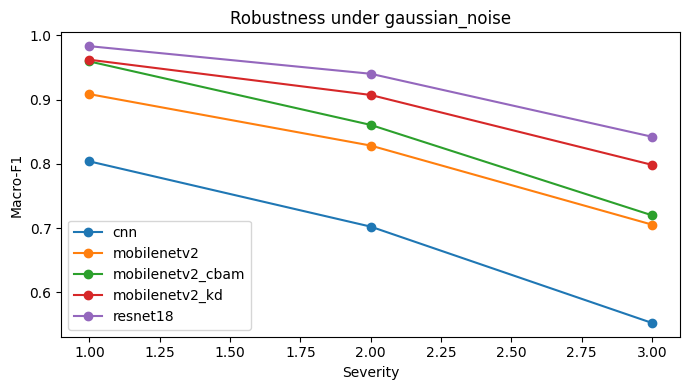

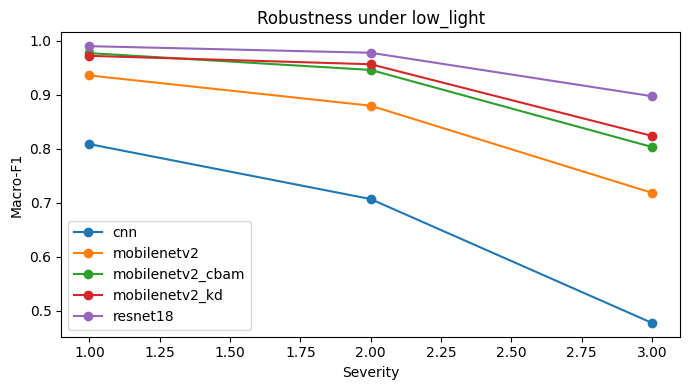

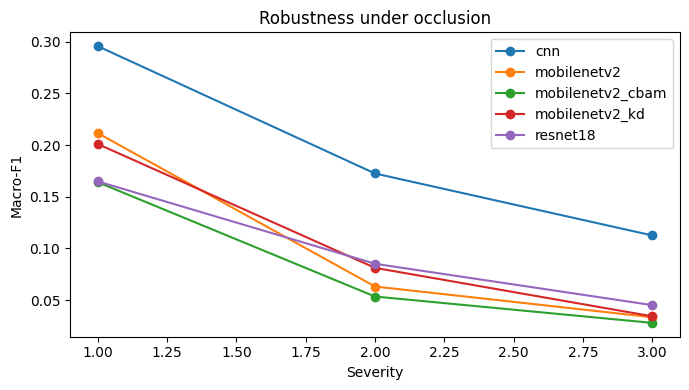

In [14]:

# ============================================================
# 10. ROBUSTNESS SEVERITY
# ============================================================

CORRUPTIONS = [
    {"type": ctype, "severity": sev}
    for ctype in ["blur", "occlusion", "low_light", "gaussian_noise"]
    for sev in ROBUSTNESS_SEVERITIES
]

def evaluate_corruption(model_name, seed, corruption, run_label="main"):
    cname = f"{corruption['type']}_s{corruption['severity']}"
    metrics_file = TABLE_DIR / f"robustness_{run_label}_{model_name}_seed{seed}_{cname}.csv"
    pred_file = PRED_DIR / f"predictions_{run_label}_{model_name}_seed{seed}_{cname}.csv"
    if metrics_file.exists() and pred_file.exists():
        return pd.read_csv(metrics_file).iloc[0].to_dict()

    loader = make_loader("test", eval_transform, shuffle=False, corruption=corruption)
    model, ckpt = load_best_model(model_name, seed, run_label=run_label)
    metrics, logits, labels, paths = evaluate_model(model, loader)
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    preds = probs.argmax(axis=1)
    confs = probs.max(axis=1)
    pd.DataFrame({
        "path": paths, "true": labels, "pred": preds, "confidence": confs
    }).to_csv(pred_file, index=False)

    row = {
        "run_label": run_label,
        "model": model_name,
        "seed": seed,
        "corruption": corruption["type"],
        "severity": corruption["severity"],
        **metrics
    }
    pd.DataFrame([row]).to_csv(metrics_file, index=False)
    return row

if any(stage in ["evaluate", "all"] for stage in RUN_STAGE):
    rows = []
    for seed in SEED_LIST:
        for model_name in EVAL_MODELS:
            for corr in CORRUPTIONS:
                try:
                    rows.append(evaluate_corruption(model_name, seed, corr, "main"))
                except FileNotFoundError as e:
                    print("Missing checkpoint; skipping:", e)

    if rows:
        rob_df = pd.DataFrame(rows)
        rob_df.to_csv(TABLE_DIR / "table_robustness_severity_per_seed.csv", index=False)
        rob_summary = rob_df.groupby(["model", "corruption", "severity"])[["accuracy", "macro_f1"]].agg(["mean", "std"]).reset_index()
        rob_summary.to_csv(TABLE_DIR / "table_robustness_severity_mean_std.csv", index=False)
        display(rob_summary.head())

        # Lines: F1 vs severity by corruption
        for corruption_type in sorted(rob_df["corruption"].unique()):
            plt.figure(figsize=(7, 4))
            sub = rob_df[rob_df["corruption"] == corruption_type]
            for model_name in sorted(sub["model"].unique()):
                s = sub[sub["model"] == model_name].groupby("severity")["macro_f1"].mean()
                plt.plot(s.index, s.values, marker="o", label=model_name)
            plt.xlabel("Severity")
            plt.ylabel("Macro-F1")
            plt.title(f"Robustness under {corruption_type}")
            plt.legend()
            save_fig(FIG_DIR / f"fig_robustness_{corruption_type}_severity.pdf")


## Auxiliary A. Random occlusion robustness check (seed 42 only)

In [15]:

# ============================================================
# AUX 2. RANDOM OCCLUSION VS CENTRAL OCCLUSION
# ============================================================
# Reviewer issue addressed: central occlusion is a worst-case test and may overestimate sensitivity.
# This cell adds support-matched random occlusion with repeated deterministic placements.

class GTSRBDatasetRandomOcclusion(Dataset):
    def __init__(self, df, transform=None, severity=3, repeat=0):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.severity = int(severity)
        self.repeat = int(repeat)
        self.frac_map = {1: 0.10, 2: 0.20, 3: 0.30}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["abs_path"]).convert("RGB")
        frac = self.frac_map[self.severity]
        w, h = img.size
        side = max(1, int(math.sqrt(frac) * min(w, h)))
        # Deterministic pseudo-random placement per image/repeat/severity.
        seed_val = abs(hash((str(row["abs_path"]), self.severity, self.repeat))) % (2**32)
        rng = np.random.default_rng(seed_val)
        x1 = int(rng.integers(0, max(1, w - side + 1)))
        y1 = int(rng.integers(0, max(1, h - side + 1)))
        img2 = img.copy()
        draw = ImageDraw.Draw(img2)
        draw.rectangle([x1, y1, x1 + side, y1 + side], fill=(0, 0, 0))
        if self.transform:
            img2 = self.transform(img2)
        return img2, int(row["ClassId"]), row["abs_path"]

def make_random_occlusion_loader(severity=3, repeat=0):
    df = split_df[split_df["split"] == "test"].copy()
    ds = GTSRBDatasetRandomOcclusion(df, transform=eval_transform, severity=severity, repeat=repeat)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

def evaluate_random_occlusion(model_name, seed, severity=3, repeat=0):
    metrics_file = TABLE_DIR / f"robustness_random_occlusion_main_{model_name}_seed{seed}_s{severity}_repeat{repeat}.csv"
    pred_file = PRED_DIR / f"predictions_main_{model_name}_seed{seed}_random_occlusion_s{severity}_repeat{repeat}.csv"
    if metrics_file.exists() and pred_file.exists():
        return pd.read_csv(metrics_file).iloc[0].to_dict()
    loader = make_random_occlusion_loader(severity=severity, repeat=repeat)
    model, _ = load_best_model(model_name, seed, run_label="main")
    metrics, logits, labels, paths = evaluate_model(model, loader)
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    preds = probs.argmax(axis=1)
    pd.DataFrame({"path": paths, "true": labels, "pred": preds, "confidence": probs.max(axis=1)}).to_csv(pred_file, index=False)
    row = {"run_label": "main", "model": model_name, "seed": seed, "corruption": "random_occlusion", "severity": severity, "repeat": repeat, **metrics}
    pd.DataFrame([row]).to_csv(metrics_file, index=False)
    return row

if ENABLE_AUXILIARY_ANALYSES and any(stage in ["evaluate", "all", "auxiliary"] for stage in RUN_STAGE):
    rows = []
    for seed in SEED_LIST:
        for model_name in EVAL_MODELS:
            for severity in [1, 2, 3]:
                for repeat in range(RANDOM_OCCLUSION_REPEATS):
                    try:
                        rows.append(evaluate_random_occlusion(model_name, seed, severity=severity, repeat=repeat))
                    except FileNotFoundError as e:
                        print("Missing checkpoint; skipping random occlusion:", e)
    if rows:
        rnd = pd.DataFrame(rows)
        rnd.to_csv(TABLE_DIR / "table_random_occlusion_per_repeat.csv", index=False)
        rnd_summary = rnd.groupby(["model", "severity"])[["accuracy", "macro_f1"]].agg(["mean", "std", "count"]).reset_index()
        rnd_summary.to_csv(TABLE_DIR / "table_random_occlusion_mean_std.csv", index=False)
        display(rnd_summary)
        # Compare S3 central against random.
        central_file = TABLE_DIR / "table_robustness_severity_per_seed_ALL_AVAILABLE.csv"
        if not central_file.exists():
            central_file = TABLE_DIR / "table_robustness_severity_per_seed.csv"
        comp_rows = []
        if central_file.exists():
            central = pd.read_csv(central_file)
            central_s3 = central[(central["corruption"].eq("occlusion")) & (central["severity"].eq(3))]
            rnd_s3 = rnd[rnd["severity"].eq(3)].groupby(["model", "seed"])["macro_f1"].agg(["mean", "std"]).reset_index()
            for _, r in rnd_s3.iterrows():
                hit = central_s3[(central_s3["model"].eq(r["model"])) & (central_s3["seed"].eq(r["seed"]))]
                if not hit.empty:
                    c = float(hit["macro_f1"].iloc[0])
                    comp_rows.append({"model": r["model"], "seed": int(r["seed"]), "central_occlusion_s3_macro_f1": c, "random_occlusion_s3_macro_f1_mean": float(r["mean"]), "random_occlusion_s3_macro_f1_std": float(r["std"]), "random_minus_central": float(r["mean"] - c)})
        if comp_rows:
            comp = pd.DataFrame(comp_rows)
            comp.to_csv(TABLE_DIR / "table_central_vs_random_occlusion_s3.csv", index=False)
            display(comp)
            plot_df = comp.groupby("model")[["central_occlusion_s3_macro_f1", "random_occlusion_s3_macro_f1_mean"]].mean().reset_index()
            x = np.arange(len(plot_df))
            width = 0.35
            plt.figure(figsize=(8, 4.5))
            plt.bar(x - width/2, plot_df["central_occlusion_s3_macro_f1"], width, label="Central S3")
            plt.bar(x + width/2, plot_df["random_occlusion_s3_macro_f1_mean"], width, label="Random S3")
            plt.xticks(x, plot_df["model"].map(MODEL_LABELS).fillna(plot_df["model"]), rotation=20, ha="right")
            plt.ylabel("Macro-F1")
            plt.title("Central vs random occlusion at severity 3")
            plt.legend()
            save_fig(FIG_DIR / "fig_central_vs_random_occlusion_s3.pdf")


## 10B. External dataset generalization: GTSDB

This stage evaluates the GTSRB-trained checkpoints on **GTSDB cropped signs** without retraining.

GTSDB is handled automatically if `gt.txt` is found. Its annotations use GTSRB-compatible class IDs, so the notebook crops each annotated sign and evaluates it as a classification sample.


Requested GTSDB root: /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset
Root exists: True
Candidate GTSDB split roots:
 - /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test
 - /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Train
 - /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset
Using YOLO image folder: /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test/images
Using YOLO label folder: /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test/labels
Image files found in this split: 300
Loaded YOLO-labeled GTSDB samples: 360
Number of classes found: 38
Class count summary:


,ClassId,count
0,1,31
1,2,22
2,3,10
3,4,37
4,5,16
5,6,2
6,7,3
7,8,10
8,9,9
9,10,17


accuracy     macro_precision      \
                                       mean std            mean std   
external_dataset model                                                
gtsdb            cnn               0.752778 NaN        0.745980 NaN   
                 mobilenetv2       0.875000 NaN        0.800348 NaN   
                 mobilenetv2_cbam  0.936111 NaN        0.842018 NaN   
                 mobilenetv2_kd    0.958333 NaN        0.888594 NaN   
                 resnet18          0.969444 NaN        0.910657 NaN   

                                  macro_recall      macro_f1     weighted_f1  \
                                          mean std      mean std        mean   
external_dataset model                                                         
gtsdb            cnn                  0.699557 NaN  0.697209 NaN    0.745540   
                 mobilenetv2          0.843619 NaN  0.797055 NaN    0.877885   
                 mobilenetv2_cbam     0.866058 NaN  0.843985 NaN    0.934995   
                 mobilenetv2_kd       0.903326 NaN  0.893360 NaN    0.957169   
                 resnet18             0.914526 NaN  0.905694 NaN    0.971540   

                                       
                                  std  
external_dataset model                 
gtsdb            cnn              NaN  
                 mobilenetv2      NaN  
                 mobilenetv2_cbam NaN  
                 mobilenetv2_kd   NaN  
                 resnet18         NaN

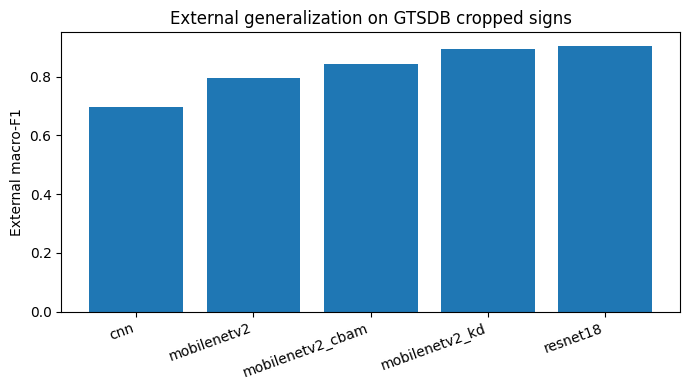

In [16]:

# ============================================================
# 10B. EXTERNAL GENERALIZATION: GTSDB
# ============================================================

external_eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class ExternalCroppedSignsDataset(Dataset):
    """Dataset for full-scene detection datasets converted into cropped classification samples."""
    def __init__(self, df, transform=None, pad_frac=0.08):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.pad_frac = pad_frac

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["abs_path"]).convert("RGB")
        w, h = img.size
        if all(c in row.index for c in ["x1", "y1", "x2", "y2"]):
            x1, y1, x2, y2 = float(row["x1"]), float(row["y1"]), float(row["x2"]), float(row["y2"])
            bw, bh = x2 - x1, y2 - y1
            pad = self.pad_frac * max(bw, bh)
            x1 = max(0, int(x1 - pad)); y1 = max(0, int(y1 - pad))
            x2 = min(w, int(x2 + pad)); y2 = min(h, int(y2 + pad))
            if x2 > x1 and y2 > y1:
                img = img.crop((x1, y1, x2, y2))
        if self.transform:
            img = self.transform(img)
        label = int(row["ClassId"])
        return img, label, row["abs_path"]

def _find_any_file(root, names):
    root = Path(root)
    if not root.exists():
        return None
    for name in names:
        hits = list(root.rglob(name))
        if hits:
            return hits[0]
    return None

def _infer_class_id_from_path(path):
    """
    Infer GTSRB-compatible ClassId from numeric class folders.
    Works for folders such as:
    Test/0/image.png
    Test/00/image.png
    Test/00000/image.png
    Test/class_14/image.png
    """
    p = Path(path)

    candidates = [
        p.parent.name,
        p.parent.parent.name if p.parent.parent else "",
        p.stem,
    ]

    for text in candidates:
        text = str(text)

        # Direct numeric folder/file name: 0, 00, 00014
        if text.isdigit():
            val = int(text)
            if 0 <= val < NUM_CLASSES:
                return val

        # Pattern such as class_14, ClassId_14, label-14
        import re
        hits = re.findall(r"(?:class|Class|label|Label|ClassId|classid)[_\-\s]*(\d+)", text)
        for h in hits:
            val = int(h)
            if 0 <= val < NUM_CLASSES:
                return val

    return None


def _find_gtsdb_data_roots(root):
    """
    Return likely places where the actual GTSDB images may live.
    Your Kaggle structure is:
    /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/GTSDB_Train_and_Test/Test
    """
    root = Path(root)
    candidates = [
        root,
        root / "GTSDB_Train_and_Test",
        root / "GTSDB_Train_and_Test" / "Test",
        root / "GTSDB_Train_and_Test" / "Train",
        root / "Test",
        root / "Train",
        root / "FullIJCNN2013",
        root / "TrainIJCNN2013",
    ]

    existing = []
    for c in candidates:
        if c.exists():
            existing.append(c)

    # Also add any nested folder actually named Test or Train
    for p in root.rglob("*"):
        if p.is_dir() and p.name.lower() in ["test", "train", "gtsdb_train_and_test", "fullijcnn2013", "trainijcnn2013"]:
            existing.append(p)

    # Remove duplicates while preserving order
    seen = set()
    unique = []
    for p in existing:
        s = str(p)
        if s not in seen:
            seen.add(s)
            unique.append(p)

    return unique

GTSDB_YOLO_TO_GTSRB = {
    1: 1,
    2: 10,
    3: 11,
    4: 12,
    5: 13,
    6: 14,
    7: 15,
    8: 16,
    9: 17,
    10: 18,
    12: 2,
    15: 22,
    16: 23,
    17: 24,
    18: 25,
    19: 26,
    21: 28,
    22: 29,
    23: 3,
    24: 30,
    25: 31,
    26: 32,
    27: 33,
    28: 34,
    29: 35,
    30: 36,
    31: 37,
    32: 38,
    33: 39,
    34: 4,
    35: 40,
    36: 20,
    37: 42,
    38: 5,
    39: 6,
    40: 7,
    41: 8,
    42: 9,
}

def load_gtsdb_external_df(root):
    root = Path(root)

    print("Requested GTSDB root:", root)
    print("Root exists:", root.exists())

    if not root.exists():
        print(f"GTSDB root not found: {root}")
        return pd.DataFrame()

    # Save folder diagnostics so we can inspect what Kaggle actually mounted.
    discovery_rows = []
    for p in root.rglob("*"):
        if len(discovery_rows) >= 500:
            break
        discovery_rows.append({
            "path": str(p),
            "name": p.name,
            "is_dir": p.is_dir(),
            "suffix": p.suffix.lower()
        })
    pd.DataFrame(discovery_rows).to_csv(TABLE_DIR / "table_gtsdb_discovery_candidates.csv", index=False)

    data_roots = _find_gtsdb_data_roots(root)
    print("Candidate GTSDB data roots:")
    for d in data_roots:
        print(" -", d)

    # ------------------------------------------------------------
    # First try official GTSDB annotation format: gt.txt / GT.txt
    # ------------------------------------------------------------
    gt_files = []
    for d in data_roots:
        for name in ["gt.txt", "GT.txt", "gt.csv", "GT.csv"]:
            gt_files.extend(list(d.rglob(name)))

    if gt_files:
        gt_path = gt_files[0]
        print("Found annotation file:", gt_path)

        rows = []
        with open(gt_path, "r", errors="ignore") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue

                # GTSDB usually uses semicolon:
                # filename;x1;y1;x2;y2;ClassId
                if ";" in line:
                    parts = line.split(";")
                elif "," in line:
                    parts = line.split(",")
                else:
                    parts = line.split()

                if len(parts) < 6:
                    continue

                fname, x1, y1, x2, y2, cls = parts[:6]

                candidate = gt_path.parent / fname
                if not candidate.exists():
                    hits = list(root.rglob(Path(fname).name))
                    candidate = hits[0] if hits else candidate

                if candidate.exists():
                    try:
                        cls_int = int(float(cls))
                        if 0 <= cls_int < NUM_CLASSES:
                            rows.append({
                                "dataset": "gtsdb",
                                "abs_path": str(candidate),
                                "x1": float(x1),
                                "y1": float(y1),
                                "x2": float(x2),
                                "y2": float(y2),
                                "ClassId": cls_int,
                                "source_category": cls_int,
                                "source_mode": "annotation"
                            })
                    except Exception:
                        continue

        df = pd.DataFrame(rows)
        if not df.empty:
            df = df[df["ClassId"].between(0, NUM_CLASSES - 1)].reset_index(drop=True)
            if DEBUG_SMALL_RUN:
                df = df.groupby("ClassId", group_keys=False).apply(
                    lambda x: x.sample(min(len(x), 5), random_state=42)
                ).reset_index(drop=True)

            df.to_csv(TABLE_DIR / "table_gtsdb_cropped_samples.csv", index=False)
            df.groupby("ClassId").size().reset_index(name="count").to_csv(
                TABLE_DIR / "table_gtsdb_class_counts.csv", index=False
            )

            print(f"Loaded GTSDB annotated cropped samples: {len(df)} from {gt_path}")
            print("Class count summary:")
            display(df.groupby("ClassId").size().reset_index(name="count").head(20))
            return df

    # ------------------------------------------------------------
    # Fallback: class-folder parsing
    # This is needed for your Kaggle dataset structure where Test
    # may already contain cropped images arranged in class folders.
    # ------------------------------------------------------------
    print("No usable gt.txt/GT.txt found. Trying class-folder image parsing...")

    image_exts = {".jpg", ".jpeg", ".png", ".ppm", ".bmp", ".webp"}
    image_paths = []

    preferred_roots = []
    for d in data_roots:
        if d.name.lower() == "test":
            preferred_roots.append(d)

    if not preferred_roots:
        preferred_roots = data_roots

    for d in preferred_roots:
        for p in d.rglob("*"):
            if p.is_file() and p.suffix.lower() in image_exts:
                image_paths.append(p)

    rows = []
    unresolved = []

    for p in image_paths:
        cls = _infer_class_id_from_path(p)
        if cls is None:
            unresolved.append(str(p))
            continue

        rows.append({
            "dataset": "gtsdb",
            "abs_path": str(p),
            "ClassId": int(cls),
            "source_category": int(cls),
            "source_mode": "class_folder"
        })

    # Save unresolved examples for debugging
    pd.DataFrame({"unresolved_path": unresolved[:500]}).to_csv(
        TABLE_DIR / "table_gtsdb_unresolved_images.csv", index=False
    )

    df = pd.DataFrame(rows)

    if df.empty:
        print("No labeled GTSDB samples could be inferred.")
        print("Number of image files found:", len(image_paths))
        print("First 20 image paths found:")
        for p in image_paths[:20]:
            print(" -", p)
        print("Saved diagnostics to:")
        print(" -", TABLE_DIR / "table_gtsdb_discovery_candidates.csv")
        print(" -", TABLE_DIR / "table_gtsdb_unresolved_images.csv")
        return pd.DataFrame()

    df = df[df["ClassId"].between(0, NUM_CLASSES - 1)].reset_index(drop=True)

    if DEBUG_SMALL_RUN:
        df = df.groupby("ClassId", group_keys=False).apply(
            lambda x: x.sample(min(len(x), 5), random_state=42)
        ).reset_index(drop=True)

    df.to_csv(TABLE_DIR / "table_gtsdb_cropped_samples.csv", index=False)
    df.groupby("ClassId").size().reset_index(name="count").to_csv(
        TABLE_DIR / "table_gtsdb_class_counts.csv", index=False
    )

    print(f"Loaded GTSDB samples from class folders: {len(df)}")
    print("Number of classes found:", df["ClassId"].nunique())
    print("Class count summary:")
    display(df.groupby("ClassId").size().reset_index(name="count").head(30))

    return df

def evaluate_external_dataset(dataset_name, external_df):
    if external_df is None or external_df.empty:
        print(f"No samples available for {dataset_name}; skipping.")
        return

    metrics_out = TABLE_DIR / f"table_external_generalization_{dataset_name}_per_seed.csv"

    loader = DataLoader(
        ExternalCroppedSignsDataset(external_df, transform=external_eval_transform),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
    )
    rows = []
    for seed in SEED_LIST:
        for model_name in EVAL_MODELS:
            try:
                model, ckpt = load_best_model(model_name, seed, run_label="main")
            except FileNotFoundError as e:
                print("Missing checkpoint; skipping external eval:", e)
                continue
            metrics, logits, labels, paths = evaluate_model(model, loader)
            probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
            preds = probs.argmax(axis=1)
            pred_df = pd.DataFrame({"dataset": dataset_name, "path": paths, "true": labels, "pred": preds, "confidence": probs.max(axis=1)})
            for c in range(NUM_CLASSES):
                pred_df[f"prob_{c}"] = probs[:, c]
            pred_df.to_csv(PRED_DIR / f"predictions_external_{dataset_name}_{model_name}_seed{seed}.csv", index=False)
            rows.append({"external_dataset": dataset_name, "model": model_name, "seed": seed, "n_samples": len(labels), **metrics})

    if rows:
        df = pd.DataFrame(rows)
        df.to_csv(metrics_out, index=False)
        summary = df.groupby(["external_dataset", "model"])[["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]].agg(["mean", "std"])
        summary.to_csv(TABLE_DIR / f"table_external_generalization_{dataset_name}_mean_std.csv")
        display(summary)

        # Compute domain drop using clean GTSRB per-seed table when available.
        clean_file = TABLE_DIR / "table_clean_performance_per_seed.csv"
        if clean_file.exists():
            clean_df = pd.read_csv(clean_file)
            drop_rows = []
            for _, r in df.iterrows():
                m = (clean_df["model"].eq(r["model"])) & (clean_df["seed"].eq(r["seed"]))
                if m.any():
                    clean_f1 = float(clean_df.loc[m, "macro_f1"].iloc[0])
                    drop_rows.append({**r.to_dict(), "gtsrb_clean_macro_f1": clean_f1, "domain_drop_macro_f1": clean_f1 - float(r["macro_f1"])})
            if drop_rows:
                drop_df = pd.DataFrame(drop_rows)
                drop_df.to_csv(TABLE_DIR / f"table_external_domain_drop_{dataset_name}.csv", index=False)

        plt.figure(figsize=(7, 4))
        plot_df = df.groupby("model")["macro_f1"].mean().reset_index()
        plt.bar(plot_df["model"], plot_df["macro_f1"])
        plt.ylabel("External macro-F1")
        plt.xticks(rotation=20, ha="right")
        plt.title(f"External generalization on {dataset_name.upper()} cropped signs")
        save_fig(FIG_DIR / f"fig_external_generalization_{dataset_name}_macro_f1.pdf")

def load_gtsdb_external_df(root):
    """
    GTSDB loader for the actual Kaggle structure:

    /kaggle/input/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset/
        GTSDB_Train_and_Test/
            Test/
                images/*.jpg
                labels/*.txt
            Train/
                images/*.jpg
                labels/*.txt

    The label files are expected to be YOLO-style:
        class_id x_center y_center width height

    where coordinates are normalized to [0, 1].
    This function converts those boxes to pixel boxes and evaluates cropped signs.
    """
    from pathlib import Path
    from PIL import Image
    import pandas as pd
    import re

    root = Path(root)

    print("Requested GTSDB root:", root)
    print("Root exists:", root.exists())

    if not root.exists():
        print(f"GTSDB root not found: {root}")
        return pd.DataFrame()

    # Save diagnostics
    discovery_rows = []
    for p in root.rglob("*"):
        if len(discovery_rows) >= 1000:
            break
        discovery_rows.append({
            "path": str(p),
            "name": p.name,
            "is_dir": p.is_dir(),
            "suffix": p.suffix.lower()
        })
    pd.DataFrame(discovery_rows).to_csv(TABLE_DIR / "table_gtsdb_discovery_candidates.csv", index=False)

    # Candidate split roots
    candidate_split_roots = [
        root / "GTSDB_Train_and_Test" / "Test",
        root / "GTSDB_Train_and_Test" / "Train",
        root / "Test",
        root / "Train",
        root,
    ]

    # Also discover nested folders that contain both images and labels
    for p in root.rglob("*"):
        if p.is_dir():
            if (p / "images").exists() and (p / "labels").exists():
                candidate_split_roots.append(p)

    # Remove duplicates
    seen = set()
    split_roots = []
    for p in candidate_split_roots:
        s = str(p)
        if p.exists() and s not in seen:
            seen.add(s)
            split_roots.append(p)

    print("Candidate GTSDB split roots:")
    for p in split_roots:
        print(" -", p)

    image_exts = [".jpg", ".jpeg", ".png", ".ppm", ".bmp", ".webp"]
    rows = []

    # Prefer Test split for external evaluation
    preferred_roots = [p for p in split_roots if p.name.lower() == "test"]
    if not preferred_roots:
        preferred_roots = split_roots

    for split_root in preferred_roots:
        images_dir = split_root / "images"
        labels_dir = split_root / "labels"

        if not images_dir.exists() or not labels_dir.exists():
            continue

        print("Using YOLO image folder:", images_dir)
        print("Using YOLO label folder:", labels_dir)

        image_files = []
        for ext in image_exts:
            image_files.extend(list(images_dir.rglob(f"*{ext}")))

        print("Image files found in this split:", len(image_files))

        for img_path in image_files:
            label_path = labels_dir / f"{img_path.stem}.txt"

            if not label_path.exists():
                # fallback: search by stem
                hits = list(labels_dir.rglob(f"{img_path.stem}.txt"))
                if hits:
                    label_path = hits[0]
                else:
                    continue

            try:
                with Image.open(img_path) as im:
                    W, H = im.size
            except Exception:
                continue

            try:
                lines = label_path.read_text(errors="ignore").strip().splitlines()
            except Exception:
                continue

            for box_idx, line in enumerate(lines):
                line = line.strip()
                if not line:
                    continue

                # Accept whitespace or comma separated values
                parts = re.split(r"[\s,]+", line)
                if len(parts) < 5:
                    continue

                try:
                    cls = int(float(parts[0]))
                    xc = float(parts[1])
                    yc = float(parts[2])
                    bw = float(parts[3])
                    bh = float(parts[4])
                except Exception:
                    continue

                # Only retain labels compatible with GTSRB 43 classes
                if cls not in GTSDB_YOLO_TO_GTSRB:
                    continue

                mapped_cls = GTSDB_YOLO_TO_GTSRB[cls]

                # YOLO normalized coordinates
                x1 = (xc - bw / 2.0) * W
                y1 = (yc - bh / 2.0) * H
                x2 = (xc + bw / 2.0) * W
                y2 = (yc + bh / 2.0) * H

                # Clip to image boundary
                x1 = max(0, min(W - 1, x1))
                y1 = max(0, min(H - 1, y1))
                x2 = max(1, min(W, x2))
                y2 = max(1, min(H, y2))

                if x2 <= x1 or y2 <= y1:
                    continue

                rows.append({
                    "dataset": "gtsdb",
                    "abs_path": str(img_path),
                    "label_path": str(label_path),
                    "box_index": box_idx,
                    "x1": float(x1),
                    "y1": float(y1),
                    "x2": float(x2),
                    "y2": float(y2),
                    "ClassId": int(mapped_cls),
                    "source_category": int(cls),
                    "source_mode": "yolo_label"
                })

        # Use Test only if it gives samples
        if rows:
            break

    df = pd.DataFrame(rows)

    if df.empty:
        print("No YOLO-labeled GTSDB samples could be loaded.")
        print("Please check whether labels exist at:")
        for p in preferred_roots:
            print(" -", p / "labels")
        return pd.DataFrame()

    df = df[df["ClassId"].between(0, NUM_CLASSES - 1)].reset_index(drop=True)

    if DEBUG_SMALL_RUN:
        df = df.groupby("ClassId", group_keys=False).apply(
            lambda x: x.sample(min(len(x), 5), random_state=42)
        ).reset_index(drop=True)

    df.to_csv(TABLE_DIR / "table_gtsdb_cropped_samples.csv", index=False)
    df.groupby("ClassId").size().reset_index(name="count").to_csv(
        TABLE_DIR / "table_gtsdb_class_counts.csv", index=False
    )

    print(f"Loaded YOLO-labeled GTSDB samples: {len(df)}")
    print("Number of classes found:", df["ClassId"].nunique())
    print("Class count summary:")
    display(df.groupby("ClassId").size().reset_index(name="count").head(30))

    return df

if any(stage in ["external", "all"] for stage in RUN_STAGE):
    if "gtsdb" in EXTERNAL_DATASETS_TO_USE:
        gtsdb_df = load_gtsdb_external_df(GTSDB_ROOT)
        evaluate_external_dataset("gtsdb", gtsdb_df)


## Auxiliary B. GTSDB class coverage and support-aware external results (seed 42 only)

In [17]:

# ============================================================
# AUX 1. GTSDB CLASS COVERAGE AND SUPPORT-AWARE EXTERNAL RESULTS
# ============================================================
# Reviewer issue addressed: 360 cropped GTSDB samples are small for 43 classes.
# This cell reports class coverage, missing classes, low-support classes, and grouped results.

if ENABLE_AUXILIARY_ANALYSES and any(stage in ["external", "all", "auxiliary"] for stage in RUN_STAGE):
    gtsdb_table = TABLE_DIR / "table_gtsdb_cropped_samples.csv"
    if gtsdb_table.exists():
        gdf = pd.read_csv(gtsdb_table)
        counts = gdf.groupby("ClassId").size().reindex(range(NUM_CLASSES), fill_value=0).reset_index(name="count")
        counts["support_group"] = pd.cut(
            counts["count"], bins=[-1, 0, 1, 4, 9, 10**9],
            labels=["missing", "n=1", "n=2-4", "n=5-9", "n>=10"]
        )
        coverage_summary = pd.DataFrame([{
            "external_set": "GTSDB cropped",
            "total_samples": int(len(gdf)),
            "total_gtsrb_classes": NUM_CLASSES,
            "represented_classes": int((counts["count"] > 0).sum()),
            "missing_classes": int((counts["count"] == 0).sum()),
            "classes_with_n_eq_1": int((counts["count"] == 1).sum()),
            "classes_with_n_lt_5": int(((counts["count"] > 0) & (counts["count"] < 5)).sum()),
            "classes_with_n_ge_10": int((counts["count"] >= 10).sum()),
        }])
        counts.to_csv(TABLE_DIR / "table_gtsdb_class_coverage_full.csv", index=False)
        coverage_summary.to_csv(TABLE_DIR / "table_gtsdb_class_coverage_summary.csv", index=False)
        display(coverage_summary)
        display(counts[counts["count"] > 0].head(50))

        # Bar plot of class counts for transparency.
        plt.figure(figsize=(9, 4))
        plt.bar(counts["ClassId"], counts["count"])
        plt.xlabel("GTSRB-compatible class ID")
        plt.ylabel("Number of cropped GTSDB samples")
        plt.title("Class coverage of cropped GTSDB external set")
        save_fig(FIG_DIR / "fig_gtsdb_class_coverage.pdf")

        # Per-class and support-group external performance from predictions.
        pred_files = sorted(PRED_DIR.glob("predictions_external_gtsdb_*_seed*.csv"))
        per_class_rows = []
        grouped_rows = []
        for pf in pred_files:
            m = re.match(r"predictions_external_gtsdb_(.+)_seed(\d+)\.csv", pf.name)
            if not m:
                continue
            model, seed = m.group(1), int(m.group(2))
            pdf = pd.read_csv(pf)
            pdf = pdf.merge(counts.rename(columns={"ClassId": "true", "count": "class_support"})[["true", "class_support", "support_group"]], on="true", how="left")
            for cls, sub in pdf.groupby("true"):
                acc = float((sub["true"] == sub["pred"]).mean())
                per_class_rows.append({"model": model, "seed": seed, "ClassId": int(cls), "support": int(len(sub)), "accuracy": acc})
            for grp, sub in pdf.groupby("support_group", observed=False):
                if len(sub) == 0 or str(grp) == "missing":
                    continue
                y_true, y_pred = sub["true"].values, sub["pred"].values
                acc = accuracy_score(y_true, y_pred)
                _, _, mf1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
                _, _, wf1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
                grouped_rows.append({"model": model, "seed": seed, "support_group": str(grp), "n_samples": len(sub), "accuracy": acc, "macro_f1": mf1, "weighted_f1": wf1})
        if per_class_rows:
            per_class_df = pd.DataFrame(per_class_rows)
            per_class_df.to_csv(TABLE_DIR / "table_gtsdb_external_per_class_per_seed.csv", index=False)
            display(per_class_df.head(20))
        if grouped_rows:
            grouped_df = pd.DataFrame(grouped_rows)
            grouped_df.to_csv(TABLE_DIR / "table_gtsdb_external_by_support_group_per_seed.csv", index=False)
            grouped_summary = grouped_df.groupby(["model", "support_group"])[["accuracy", "macro_f1", "weighted_f1"]].agg(["mean", "std", "count"])
            grouped_summary.to_csv(TABLE_DIR / "table_gtsdb_external_by_support_group_mean_std.csv")
            display(grouped_summary)
    else:
        print("GTSDB cropped sample table not found yet. Run the external stage first.")


## 11. CBAM/augmentation ablation evaluation

This creates the ablation table required to separate the effect of augmentation from the effect of CBAM.


In [18]:

# ============================================================
# 11. ABLATION EVALUATION
# ============================================================

if any(stage in ["evaluate", "all"] for stage in RUN_STAGE):
    rows = []
    for seed in SEED_LIST:
        for variant in ABLATION_VARIANTS:
            variant_name = variant["name"]
            model_name = "mobilenetv2_cbam" if variant["cbam"] else "mobilenetv2"
            run_label = f"ablation_{variant_name}"
            try:
                row = evaluate_and_save_clean(model_name, seed, run_label=run_label, output_name=f"{run_label}_seed{seed}")
                row["variant"] = variant_name
                row["augmentation"] = variant["augmentation"]
                row["cbam"] = variant["cbam"]
                rows.append(row)
            except FileNotFoundError as e:
                print("Missing ablation checkpoint; skipping:", e)

    # Also evaluate robustness for ablations at severity 2 only to reduce runtime
    ab_rob_rows = []
    for seed in SEED_LIST:
        for variant in ABLATION_VARIANTS:
            variant_name = variant["name"]
            model_name = "mobilenetv2_cbam" if variant["cbam"] else "mobilenetv2"
            run_label = f"ablation_{variant_name}"
            for corr in [{"type": "blur", "severity": 2}, {"type": "occlusion", "severity": 2}, {"type": "low_light", "severity": 2}]:
                try:
                    rr = evaluate_corruption(model_name, seed, corr, run_label=run_label)
                    rr["variant"] = variant_name
                    rr["augmentation"] = variant["augmentation"]
                    rr["cbam"] = variant["cbam"]
                    ab_rob_rows.append(rr)
                except FileNotFoundError as e:
                    print("Missing ablation checkpoint; skipping:", e)

    if rows:
        ab_clean = pd.DataFrame(rows)
        ab_clean.to_csv(TABLE_DIR / "table_cbam_augmentation_ablation_clean.csv", index=False)
        display(ab_clean)

    if ab_rob_rows:
        ab_rob = pd.DataFrame(ab_rob_rows)
        ab_rob.to_csv(TABLE_DIR / "table_cbam_augmentation_ablation_robustness.csv", index=False)
        display(ab_rob.head())


Missing ablation checkpoint; skipping: Missing checkpoint: /kaggle/working/revision_outputs_multiseed/checkpoints/ablation_mobilenetv2_noaug_nocbam_mobilenetv2_seed777_best.pth
Missing ablation checkpoint; skipping: Missing checkpoint: /kaggle/working/revision_outputs_multiseed/checkpoints/ablation_mobilenetv2_noaug_cbam_mobilenetv2_cbam_seed777_best.pth
Missing ablation checkpoint; skipping: Missing checkpoint: /kaggle/working/revision_outputs_multiseed/checkpoints/ablation_mobilenetv2_noaug_nocbam_mobilenetv2_seed777_best.pth
Missing ablation checkpoint; skipping: Missing checkpoint: /kaggle/working/revision_outputs_multiseed/checkpoints/ablation_mobilenetv2_noaug_nocbam_mobilenetv2_seed777_best.pth
Missing ablation checkpoint; skipping: Missing checkpoint: /kaggle/working/revision_outputs_multiseed/checkpoints/ablation_mobilenetv2_noaug_nocbam_mobilenetv2_seed777_best.pth
Missing ablation checkpoint; skipping: Missing checkpoint: /kaggle/working/revision_outputs_multiseed/checkpoint

## 12. Calibration metrics and reliability diagrams

This section computes Expected Calibration Error, Maximum Calibration Error, NLL, and Brier score from saved clean predictions.


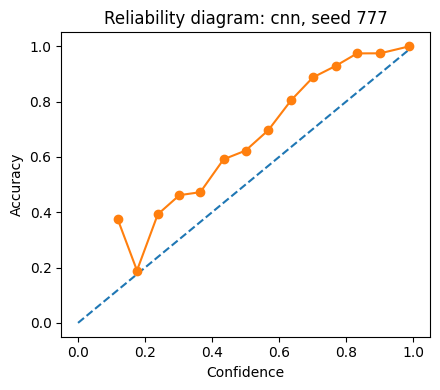

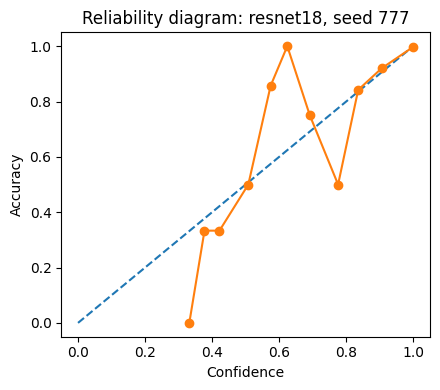

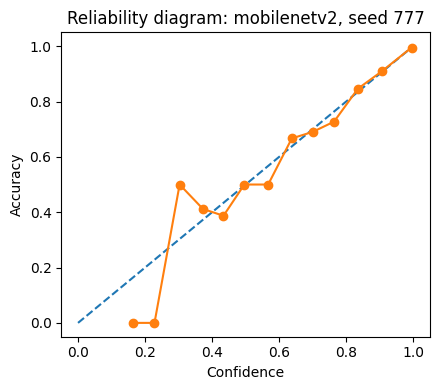

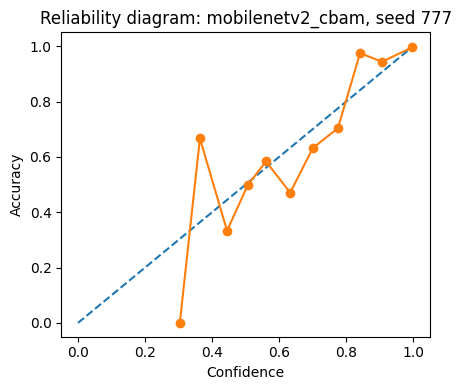

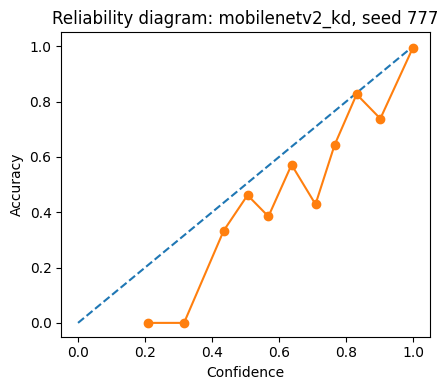

ECE           MCE           NLL         Brier    
                      mean std      mean std      mean std      mean std
model                                                                   
cnn               0.083261 NaN  0.256688 NaN  0.508378 NaN  0.236727 NaN
mobilenetv2       0.003684 NaN  0.228086 NaN  0.143051 NaN  0.063846 NaN
mobilenetv2_cbam  0.005611 NaN  0.303633 NaN  0.053739 NaN  0.024812 NaN
mobilenetv2_kd    0.009273 NaN  0.316200 NaN  0.078775 NaN  0.030366 NaN
resnet18          0.004337 NaN  0.375767 NaN  0.034801 NaN  0.014023 NaN

In [19]:

# ============================================================
# 12. CALIBRATION
# ============================================================

def calibration_metrics_from_probs(y_true, probs, n_bins=15):
    y_true = np.asarray(y_true)
    probs = np.asarray(probs)
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == y_true).astype(float)

    ece, mce = 0.0, 0.0
    bin_rows = []
    bins = np.linspace(0, 1, n_bins + 1)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if mask.sum() == 0:
            continue
        acc_bin = correct[mask].mean()
        conf_bin = conf[mask].mean()
        gap = abs(acc_bin - conf_bin)
        ece += (mask.sum() / len(y_true)) * gap
        mce = max(mce, gap)
        bin_rows.append({"bin_low": lo, "bin_high": hi, "accuracy": acc_bin, "confidence": conf_bin, "count": int(mask.sum())})

    eps = 1e-12
    nll = -np.mean(np.log(probs[np.arange(len(y_true)), y_true] + eps))
    onehot = np.eye(probs.shape[1])[y_true]
    brier = np.mean(np.sum((probs - onehot) ** 2, axis=1))
    return {"ECE": ece, "MCE": mce, "NLL": nll, "Brier": brier}, pd.DataFrame(bin_rows)

if any(stage in ["evaluate", "all"] for stage in RUN_STAGE):
    rows = []
    for seed in SEED_LIST:
        for model_name in EVAL_MODELS:
            pred_file = PRED_DIR / f"predictions_clean_main_{model_name}_seed{seed}.csv"
            if not pred_file.exists():
                continue
            dfp = pd.read_csv(pred_file)
            prob_cols = [f"prob_{i}" for i in range(NUM_CLASSES)]
            probs = dfp[prob_cols].values
            y_true = dfp["true"].values
            mets, bins_df = calibration_metrics_from_probs(y_true, probs, n_bins=15)
            row = {"model": model_name, "seed": seed, **mets}
            rows.append(row)
            bins_df.to_csv(TABLE_DIR / f"calibration_bins_{model_name}_seed{seed}.csv", index=False)

            plt.figure(figsize=(4.5, 4))
            plt.plot([0, 1], [0, 1], linestyle="--")
            plt.plot(bins_df["confidence"], bins_df["accuracy"], marker="o")
            plt.xlabel("Confidence")
            plt.ylabel("Accuracy")
            plt.title(f"Reliability diagram: {model_name}, seed {seed}")
            save_fig(FIG_DIR / f"fig_reliability_{model_name}_seed{seed}.pdf")

    if rows:
        cal_df = pd.DataFrame(rows)
        cal_df.to_csv(TABLE_DIR / "table_calibration_metrics_per_seed.csv", index=False)
        cal_summary = cal_df.groupby("model")[["ECE", "MCE", "NLL", "Brier"]].agg(["mean", "std"])
        cal_summary.to_csv(TABLE_DIR / "table_calibration_metrics_mean_std.csv")
        display(cal_summary)


## Auxiliary C. Knowledge-distillation sensitivity analysis (seed 42 only)

In [20]:

# ============================================================
# AUX 3. KNOWLEDGE-DISTILLATION HYPERPARAMETER SENSITIVITY
# ============================================================
# Reviewer issue addressed: T=4.0 and alpha=0.35 need rationale/sensitivity.

if ENABLE_AUXILIARY_ANALYSES:
    print("KD sensitivity grid:", KD_SENSITIVITY_GRID)
    pd.DataFrame(KD_SENSITIVITY_GRID).to_csv(TABLE_DIR / "table_kd_sensitivity_grid.csv", index=False)


def kd_label(T, alpha):
    return f"kd_sens_T{str(T).replace('.', 'p')}_a{str(alpha).replace('.', 'p')}"

def train_kd_student_custom(seed, temperature, alpha, max_epochs=KD_MAX_EPOCHS, patience=KD_PATIENCE):
    set_seed(seed)
    run_label = kd_label(temperature, alpha)
    final_marker = STATUS_DIR / f"done_training_{run_label}_{KD_STUDENT_MODEL}_seed{seed}.txt"
    if final_marker.exists():
        print(f"Already completed KD sensitivity: seed={seed}, T={temperature}, alpha={alpha}")
        return
    teacher, _ = load_best_model(KD_TEACHER_MODEL, seed, run_label="main")
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False
    student = get_model(KD_STUDENT_MODEL).to(DEVICE)
    train_loader, val_loader = get_train_val_loaders(use_augmentation=True)
    optimizer = torch.optim.AdamW(student.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5)
    amp_enabled = bool(USE_AMP and DEVICE == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    ckpt_last = CHECKPOINT_DIR / f"{run_label}_{KD_STUDENT_MODEL}_seed{seed}_last.pth"
    ckpt_best = CHECKPOINT_DIR / f"{run_label}_{KD_STUDENT_MODEL}_seed{seed}_best.pth"
    log_file = LOG_DIR / f"training_log_{run_label}_{KD_STUDENT_MODEL}_seed{seed}.csv"
    start_epoch, best_val_f1, best_epoch, history = 0, -1, -1, []
    epochs_without_improve = 0
    if ckpt_last.exists():
        ckpt = torch.load(ckpt_last, map_location=DEVICE)
        student.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        start_epoch = int(ckpt["epoch"]) + 1
        best_val_f1 = ckpt.get("best_val_f1", -1)
        best_epoch = ckpt.get("best_epoch", -1)
        history = ckpt.get("history", [])
        epochs_without_improve = ckpt.get("epochs_without_improve", 0)
    for epoch in range(start_epoch, max_epochs):
        student.train()
        train_loss, correct, total = 0.0, 0, 0
        t0 = time.time()
        for b, (x, y, _) in enumerate(train_loader):
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=amp_enabled):
                    teacher_logits = teacher(x)
            with torch.cuda.amp.autocast(enabled=amp_enabled):
                student_logits = student(x)
                loss, _, _ = distillation_loss(student_logits, teacher_logits, y, temperature=temperature, alpha=alpha)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item() * x.size(0)
            correct += (student_logits.argmax(dim=1) == y).sum().item()
            total += x.size(0)
            if DEBUG_SMALL_RUN and b >= DEBUG_MAX_BATCHES:
                break
        train_loss /= max(total, 1)
        train_acc = correct / max(total, 1)
        val_metrics, _, _, _ = evaluate_model(student, val_loader)
        scheduler.step(val_metrics["macro_f1"])
        row = {"epoch": epoch, "seed": seed, "temperature": temperature, "alpha": alpha, "train_loss": train_loss, "train_accuracy": train_acc, **{f"val_{k}": v for k, v in val_metrics.items()}, "epoch_seconds": time.time()-t0}
        history.append(row)
        improved = val_metrics["macro_f1"] > best_val_f1
        if improved:
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            epochs_without_improve = 0
            torch.save({"epoch": epoch, "model_state_dict": student.state_dict(), "optimizer_state_dict": optimizer.state_dict(), "best_val_f1": best_val_f1, "best_epoch": best_epoch, "history": history, "temperature": temperature, "alpha": alpha}, ckpt_best)
        else:
            epochs_without_improve += 1
        torch.save({"epoch": epoch, "model_state_dict": student.state_dict(), "optimizer_state_dict": optimizer.state_dict(), "best_val_f1": best_val_f1, "best_epoch": best_epoch, "history": history, "epochs_without_improve": epochs_without_improve, "temperature": temperature, "alpha": alpha}, ckpt_last)
        pd.DataFrame(history).to_csv(log_file, index=False)
        print(f"KD sens {run_label} seed={seed} epoch={epoch} val_f1={val_metrics['macro_f1']:.4f} best={best_val_f1:.4f}")
        if epochs_without_improve >= patience:
            break
    final_marker.write_text("done")

if ENABLE_AUXILIARY_ANALYSES and any(stage in ["all", "auxiliary", "kd_sensitivity"] for stage in RUN_STAGE):
    sens_rows = []
    for cfg in KD_SENSITIVITY_GRID:
        T, alpha = float(cfg["temperature"]), float(cfg["alpha"])
        run_label = kd_label(T, alpha)
        try:
            train_kd_student_custom(SEED_LIST[0], T, alpha)
            row = evaluate_and_save_clean(KD_STUDENT_MODEL, SEED_LIST[0], run_label=run_label, output_name=f"{run_label}_{KD_STUDENT_MODEL}_seed{SEED_LIST[0]}")
            pred_file = PRED_DIR / f"predictions_clean_{run_label}_{KD_STUDENT_MODEL}_seed{SEED_LIST[0]}.csv"
            if pred_file.exists():
                dfp = pd.read_csv(pred_file)
                prob_cols = [f"prob_{i}" for i in range(NUM_CLASSES)]
                mets, _ = calibration_metrics_from_probs(dfp["true"].values, dfp[prob_cols].values, n_bins=15)
                row.update(mets)
            row.update({"temperature": T, "alpha": alpha})
            sens_rows.append(row)
        except FileNotFoundError as e:
            print("Missing teacher checkpoint; skipping KD sensitivity:", e)
    if sens_rows:
        sens = pd.DataFrame(sens_rows)
        sens.to_csv(TABLE_DIR / "table_kd_sensitivity_clean_calibration_seed42.csv", index=False)
        display(sens[["temperature", "alpha", "accuracy", "macro_f1", "ECE", "NLL", "Brier"]])
        plt.figure(figsize=(6, 4))
        labels = [f"T={r.temperature}, a={r.alpha}" for _, r in sens.iterrows()]
        plt.bar(labels, sens["macro_f1"])
        plt.ylabel("Macro-F1")
        plt.title("KD sensitivity: clean macro-F1")
        plt.xticks(rotation=25, ha="right")
        save_fig(FIG_DIR / "fig_kd_sensitivity_macro_f1_seed42.pdf")


## 13. Statistical testing

This section uses saved predictions for McNemar tests and seed-level Wilcoxon tests.


In [22]:

# ============================================================
# 13. STATISTICAL TESTING ACROSS ALL AVAILABLE SEEDS
# ============================================================

from scipy.stats import wilcoxon
from scipy.stats import wilcoxon, binomtest


FIXED_SEED = SEED_LIST[0] if isinstance(SEED_LIST, (list, tuple)) else SEED_LIST

def mcnemar_test(y_true, pred_a, pred_b):
    """Exact two-sided McNemar/binomial test for paired classifier disagreements."""
    a_correct = pred_a == y_true
    b_correct = pred_b == y_true
    n01 = np.sum((~a_correct) & (b_correct))
    n10 = np.sum((a_correct) & (~b_correct))
    n = int(n01 + n10)

    if n == 0:
        return {"n01": int(n01), "n10": int(n10), "p_value": 1.0}

    p = binomtest(min(int(n01), int(n10)), n=n, p=0.5, alternative="two-sided").pvalue
    return {"n01": int(n01), "n10": int(n10), "p_value": float(p)}

if any(stage in ["evaluate", "all"] for stage in RUN_STAGE):
    rows = []

    # SINGLE SEED ONLY
    seed = FIXED_SEED

    for i, m1 in enumerate(EVAL_MODELS):
        for m2 in EVAL_MODELS[i+1:]:
            f1 = PRED_DIR / f"predictions_clean_main_{m1}_seed{seed}.csv"
            f2 = PRED_DIR / f"predictions_clean_main_{m2}_seed{seed}.csv"

            if not (f1.exists() and f2.exists()):
                continue

            d1, d2 = pd.read_csv(f1), pd.read_csv(f2)

            res = mcnemar_test(d1["true"].values, d1["pred"].values, d2["pred"].values)

            rows.append({
                "seed": seed,
                "model_A": m1,
                "model_B": m2,
                **res
            })

    if rows:
        mcnemar_df = pd.DataFrame(rows)
        mcnemar_df.to_csv(TABLE_DIR / "table_mcnemar_single_seed.csv", index=False)
        display(mcnemar_df)

    # ============================================================
    # Wilcoxon (still works but now single seed => usually skipped)
    # ============================================================

    clean_file = TABLE_DIR / "table_clean_performance_per_seed_ALL_AVAILABLE.csv"
    fallback_clean_file = TABLE_DIR / "table_clean_performance_per_seed.csv"

    if clean_file.exists():
        clean_df = pd.read_csv(clean_file)
    elif fallback_clean_file.exists():
        clean_df = pd.read_csv(fallback_clean_file)
    else:
        clean_df = pd.DataFrame()

    # With single seed, Wilcoxon is NOT meaningful (needs multiple seeds)
    if not clean_df.empty:
        print("Wilcoxon skipped: multiple seeds required for statistical test.")


,seed,model_A,model_B,n01,n10,p_value
0,777,cnn,resnet18,621,18,3.493978e-158
1,777,cnn,mobilenetv2,553,87,7.383982e-84
2,777,cnn,mobilenetv2_cbam,598,29,2.919953e-139
3,777,cnn,mobilenetv2_kd,596,37,6.667992e-131
4,777,resnet18,mobilenetv2,20,157,1.465608e-27
5,777,resnet18,mobilenetv2_cbam,24,58,2.219640e-04
6,777,resnet18,mobilenetv2_kd,16,60,3.850978e-07
7,777,mobilenetv2,mobilenetv2_cbam,144,41,1.256658e-14
8,777,mobilenetv2,mobilenetv2_kd,138,45,3.507933e-12
9,777,mobilenetv2_cbam,mobilenetv2_kd,51,61,3.951934e-01


Wilcoxon skipped: multiple seeds required for statistical test.


## 14. Computational efficiency profiling

This reports parameter count, model size, inference time, FPS, and peak GPU memory.


,model,seed_for_checkpoint,parameters,trainable_parameters,model_size_mb,trained_epochs,total_training_time_sec,mean_epoch_time_sec,inference_sec_per_image,fps_batch1,peak_gpu_memory_mb
0,cnn,777,319979,319979,1.220623,25,1534.718413,61.388737,0.000372,2690.665786,288.710938
1,resnet18,777,11198571,11198571,42.755932,25,1445.665337,57.826613,0.002039,490.499627,1283.829102
2,mobilenetv2,777,2278955,2278955,8.824047,11,671.067174,61.006107,0.004780,209.197854,958.999023
3,mobilenetv2_cbam,777,2483853,2483853,9.605671,19,1103.056144,58.055587,0.005302,188.612312,284.868164
4,mobilenetv2_kd,777,2278955,2278955,8.824047,15,863.685283,57.579019,0.004888,204.590165,57.479492


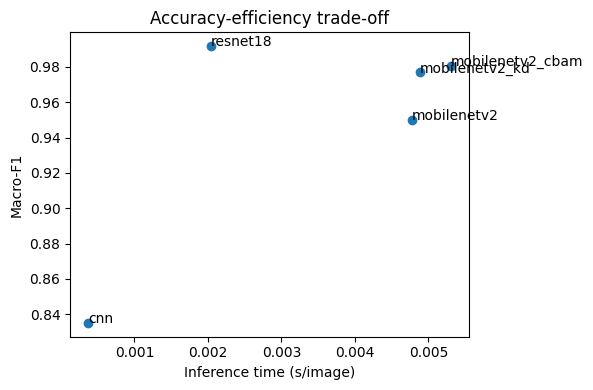

In [23]:

# ============================================================
# 14. EFFICIENCY PROFILING
# ============================================================

@torch.no_grad()
def profile_inference(model, batch_size=1, repeats=200, warmup=30):
    model.eval()
    dummy = torch.randn(batch_size, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()
    for _ in range(warmup):
        _ = model(dummy)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(repeats):
        _ = model(dummy)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - t0
    images = repeats * batch_size
    sec_per_image = elapsed / images
    fps = images / elapsed
    peak_mem = torch.cuda.max_memory_allocated() / (1024**2) if DEVICE == "cuda" else np.nan
    return sec_per_image, fps, peak_mem

if any(stage in ["evaluate", "all"] for stage in RUN_STAGE):
    rows = []
    for model_name in EVAL_MODELS:
        seed = SEED_LIST[0]
        try:
            model, ckpt = load_best_model(model_name, seed, run_label="main")
        except FileNotFoundError:
            continue
        params, trainable = count_parameters(model)
        sec_img, fps, peak_mem = profile_inference(model, batch_size=1)

        # Training-time accounting from the saved per-epoch logs.
        log_file = LOG_DIR / f"training_log_main_{model_name}_seed{seed}.csv"
        if log_file.exists():
            log_df = pd.read_csv(log_file)
            total_training_time_sec = float(log_df["epoch_time_sec"].sum()) if "epoch_time_sec" in log_df else np.nan
            mean_epoch_time_sec = float(log_df["epoch_time_sec"].mean()) if "epoch_time_sec" in log_df else np.nan
            trained_epochs = int(log_df["epoch"].max() + 1) if "epoch" in log_df and len(log_df) else np.nan
        else:
            total_training_time_sec, mean_epoch_time_sec, trained_epochs = np.nan, np.nan, np.nan

        rows.append({
            "model": model_name,
            "seed_for_checkpoint": seed,
            "parameters": params,
            "trainable_parameters": trainable,
            "model_size_mb": model_size_mb(model),
            "trained_epochs": trained_epochs,
            "total_training_time_sec": total_training_time_sec,
            "mean_epoch_time_sec": mean_epoch_time_sec,
            "inference_sec_per_image": sec_img,
            "fps_batch1": fps,
            "peak_gpu_memory_mb": peak_mem,
        })
    if rows:
        eff_df = pd.DataFrame(rows)
        eff_df.to_csv(TABLE_DIR / "table_efficiency_profile.csv", index=False)
        display(eff_df)

        plt.figure(figsize=(6, 4))
        # merge with clean metrics
        clean_file = TABLE_DIR / "table_clean_performance_mean_std.csv"
        clean_per_seed = TABLE_DIR / "table_clean_performance_per_seed.csv"
        if clean_per_seed.exists():
            cdf = pd.read_csv(clean_per_seed)
            cmean = cdf.groupby("model")["macro_f1"].mean().reset_index()
            merged = eff_df.merge(cmean, on="model", how="left")
            plt.scatter(merged["inference_sec_per_image"], merged["macro_f1"])
            for _, r in merged.iterrows():
                plt.text(r["inference_sec_per_image"], r["macro_f1"], r["model"])
            plt.xlabel("Inference time (s/image)")
            plt.ylabel("Macro-F1")
            plt.title("Accuracy-efficiency trade-off")
            save_fig(FIG_DIR / "fig_accuracy_efficiency_tradeoff.pdf")


## 15. Grad-CAM and simple localization metric

This section creates Grad-CAM figures and a simple concentration metric. If ROI columns are present in GTSRB CSV, it uses them; otherwise, it uses the center crop region as an approximate sign region.


In [27]:
MODEL_ORDER = ["cnn", "resnet18", "mobilenetv2", "mobilenetv2_cbam", "mobilenetv2_kd"]
MODEL_LABELS = {
    "cnn": "BaselineCNN",
    "resnet18": "ResNet18",
    "mobilenetv2": "MobileNetV2",
    "mobilenetv2_cbam": "MobileNetV2+CBAM",
    "mobilenetv2_kd": "MobileNetV2-KD",
}


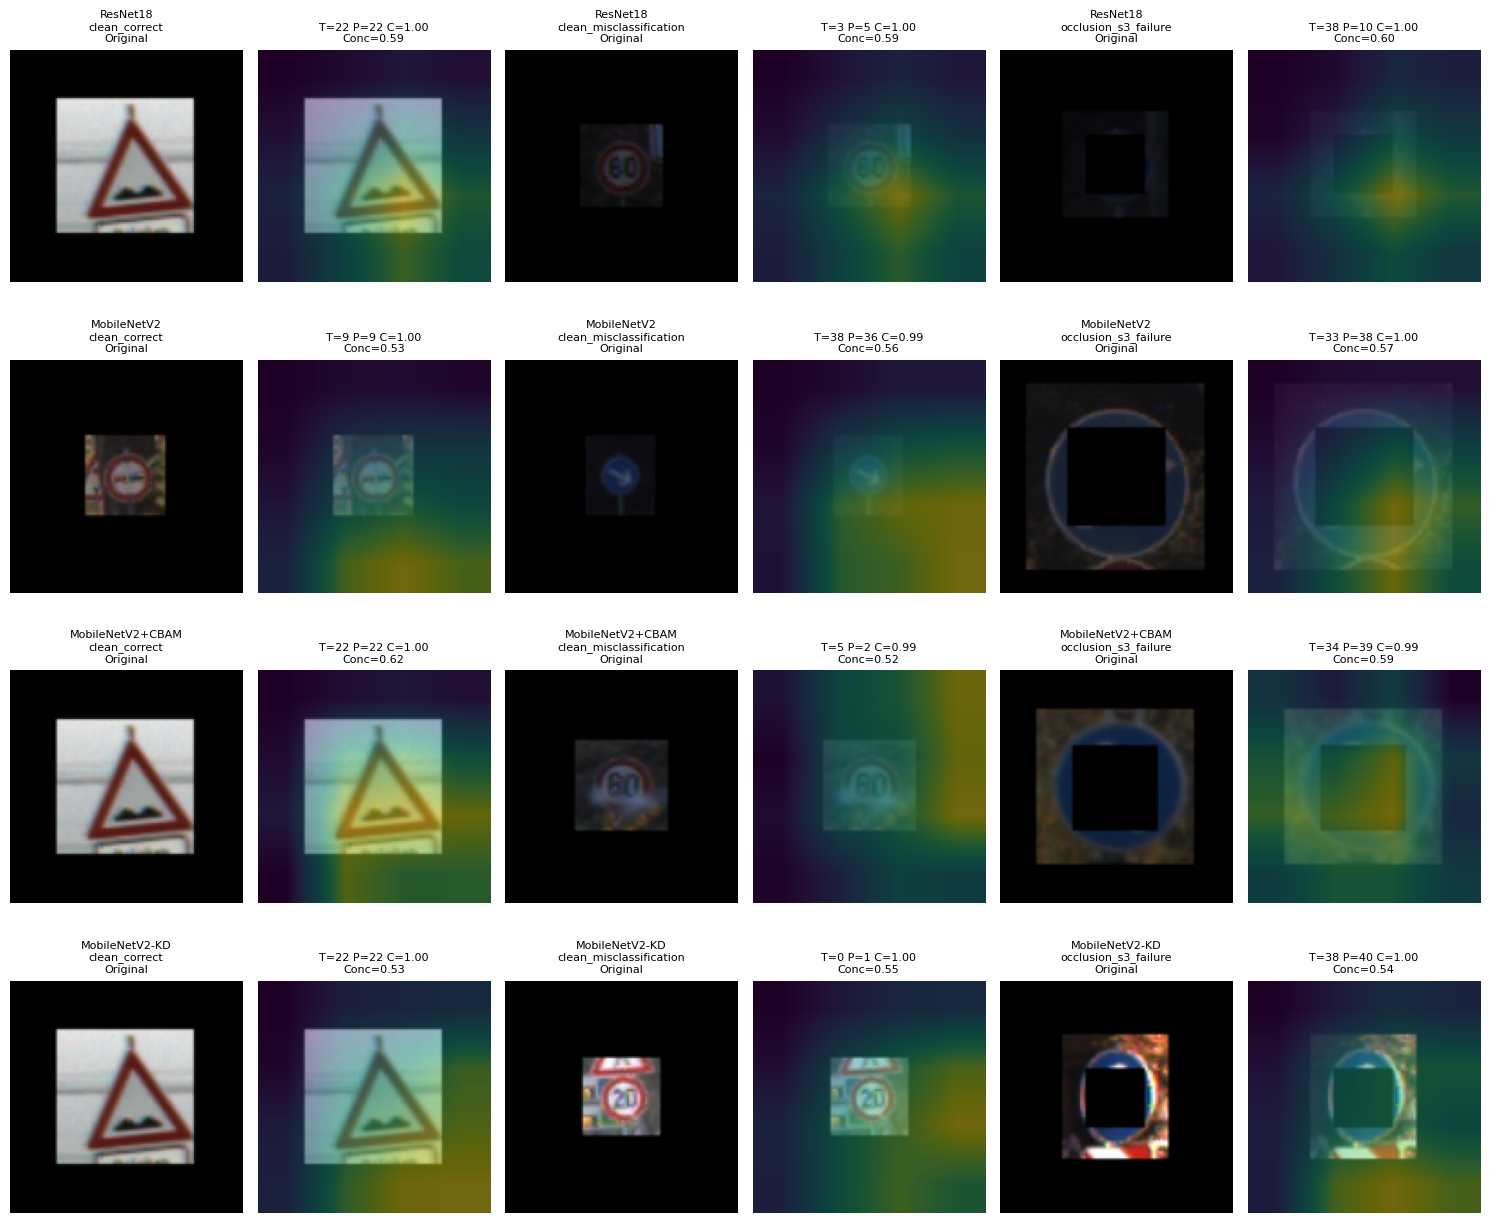

,model,mean_concentration,std_concentration,mean_confidence,accuracy,n
0,mobilenetv2,0.556571,0.034415,0.956804,0.956389,3921
1,mobilenetv2_cbam,0.563616,0.039016,0.983469,0.982657,3921
2,mobilenetv2_kd,0.542242,0.034740,0.989353,0.980362,3921
3,resnet18,0.608354,0.017304,0.993499,0.991329,3921


,model,pearson_concentration_confidence,spearman_concentration_confidence,mean_concentration_correct,mean_concentration_incorrect,n_incorrect
0,mobilenetv2,0.011806,0.128236,0.556663,0.554556,171
1,mobilenetv2_cbam,0.028347,-0.016016,0.563890,0.548112,68
2,mobilenetv2_kd,-0.066554,-0.282291,0.542090,0.549820,77
3,resnet18,-0.015936,-0.107003,0.608459,0.596373,34


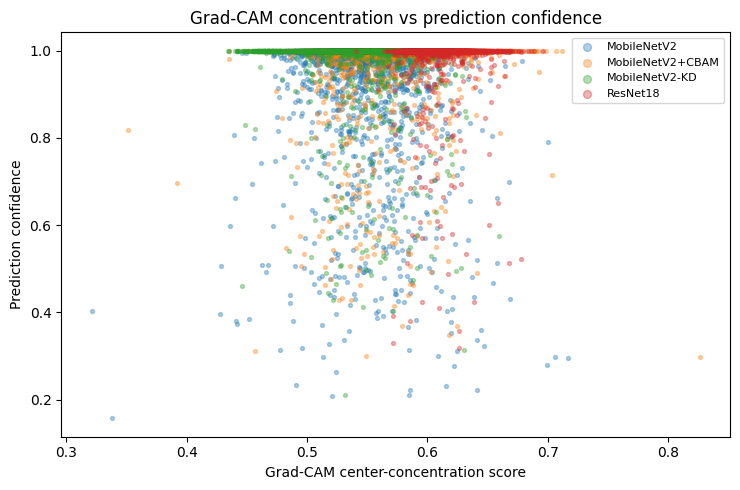

In [33]:
RUN_STAGE = ["all"]
# ============================================================
# 15. GRAD-CAM: CORRECT, MISCLASSIFICATION, FAILURE CASES + QUANTIFICATION
# ============================================================
# Reviewer issue addressed: the old figure showed the same correct class for all models.
# This version creates comparable qualitative cases and quantifies concentration/confidence relations.
MODEL_ORDER = ["cnn", "resnet18", "mobilenetv2", "mobilenetv2_cbam", "mobilenetv2_kd"]
MODEL_LABELS = {
    "cnn": "BaselineCNN",
    "resnet18": "ResNet18",
    "mobilenetv2": "MobileNetV2",
    "mobilenetv2_cbam": "MobileNetV2+CBAM",
    "mobilenetv2_kd": "MobileNetV2-KD",
}
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.h1 = target_layer.register_forward_hook(self.save_activation)
        self.h2 = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove(self):
        self.h1.remove()
        self.h2.remove()

    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        score = logits[:, class_idx].sum()
        score.backward(retain_graph=True)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, logits.detach()

def get_target_layer(model_name, model):
    if model_name == "cnn":
        return model.features[-3]
    if model_name == "resnet18":
        return model.layer4[-1].conv2
    if model_name in ["mobilenetv2", "mobilenetv2_kd", "mobilenetv2_cbam"]:
        return model.features[-1]
    return None

def denormalize_tensor(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std = torch.tensor(IMAGENET_STD).view(3,1,1)
    return torch.clamp(t.cpu() * std + mean, 0, 1)

def heatmap_concentration(cam, center_frac=0.70):
    h, w = cam.shape
    ch, cw = int(h * center_frac), int(w * center_frac)
    y1, x1 = (h - ch)//2, (w - cw)//2
    center_energy = cam[y1:y1+ch, x1:x1+cw].sum()
    total_energy = cam.sum() + 1e-8
    return float(center_energy / total_energy)

def load_eval_image_from_path(path, corruption=None):
    img = Image.open(path).convert("RGB")
    # Apply the same corruption used in robustness if requested.
    if corruption is not None:
        tmp_ds = GTSRBDataset(pd.DataFrame([{"abs_path": path, "ClassId": 0}]), transform=None, corruption=corruption)
        img = tmp_ds._apply_corruption(img)
    return eval_transform(img).unsqueeze(0)

def choose_gradcam_cases(model_name, seed):
    clean_pred = PRED_DIR / f"predictions_clean_main_{model_name}_seed{seed}.csv"
    occ_pred = PRED_DIR / f"predictions_main_{model_name}_seed{seed}_occlusion_s3.csv"
    blur_pred = PRED_DIR / f"predictions_main_{model_name}_seed{seed}_blur_s3.csv"
    if not clean_pred.exists():
        return []
    cdf = pd.read_csv(clean_pred)
    cases = []
    correct = cdf[cdf["true"].eq(cdf["pred"])].sort_values("confidence", ascending=False)
    if not correct.empty:
        r = correct.iloc[0]
        cases.append({"case_type": "clean_correct", "path": r["path"], "true": int(r["true"]), "pred": int(r["pred"]), "confidence": float(r["confidence"]), "corruption": None})
    wrong = cdf[~cdf["true"].eq(cdf["pred"])].sort_values("confidence", ascending=False)
    if not wrong.empty:
        r = wrong.iloc[0]
        cases.append({"case_type": "clean_misclassification", "path": r["path"], "true": int(r["true"]), "pred": int(r["pred"]), "confidence": float(r["confidence"]), "corruption": None})
    else:
        # If model has no clean mistakes, use the lowest-confidence correct sample as an uncertainty case.
        r = correct.sort_values("confidence", ascending=True).iloc[0]
        cases.append({"case_type": "clean_low_confidence", "path": r["path"], "true": int(r["true"]), "pred": int(r["pred"]), "confidence": float(r["confidence"]), "corruption": None})
    for pf, corr in [(occ_pred, {"type": "occlusion", "severity": 3}), (blur_pred, {"type": "blur", "severity": 3})]:
        if pf.exists():
            rdf = pd.read_csv(pf)
            fail = rdf[~rdf["true"].eq(rdf["pred"])].sort_values("confidence", ascending=False)
            if not fail.empty:
                r = fail.iloc[0]
                cases.append({"case_type": f"{corr['type']}_s3_failure", "path": r["path"], "true": int(r["true"]), "pred": int(r["pred"]), "confidence": float(r["confidence"]), "corruption": corr})
                break
    return cases[:3]

def compute_gradcam_quantification(model_name, seed, max_samples=None):
    out_csv = TABLE_DIR / f"table_gradcam_concentration_confidence_{model_name}_seed{seed}.csv"
    if out_csv.exists():
        return pd.read_csv(out_csv)
    model, _ = load_best_model(model_name, seed, run_label="main")
    cam_engine = GradCAM(model, get_target_layer(model_name, model))
    loader = make_loader("test", eval_transform, batch_size=1, shuffle=False)
    rows = []
    for idx, (x, y, paths) in enumerate(loader):
        x = x.to(DEVICE)
        true = int(y.item())
        cam, logits = cam_engine(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred = int(np.argmax(probs))
        conf = float(np.max(probs))
        conc = heatmap_concentration(cam)
        rows.append({"model": model_name, "seed": seed, "path": paths[0], "true": true, "pred": pred, "correct": bool(pred == true), "confidence": conf, "heatmap_center_concentration": conc})
        if max_samples is not None and len(rows) >= max_samples:
            break
    cam_engine.remove()
    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    return df

def make_gradcam_comparative_figure(seed=42):
    models_for_xai = ["resnet18", "mobilenetv2", "mobilenetv2_cbam", "mobilenetv2_kd"]
    fig_rows = []
    quant_rows = []
    for model_name in models_for_xai:
        try:
            qdf = compute_gradcam_quantification(model_name, seed)
            quant_rows.append(qdf)
            model, _ = load_best_model(model_name, seed, run_label="main")
            cam_engine = GradCAM(model, get_target_layer(model_name, model))
            for case in choose_gradcam_cases(model_name, seed):
                x = load_eval_image_from_path(case["path"], corruption=case["corruption"]).to(DEVICE)
                cam, logits = cam_engine(x)
                conc = heatmap_concentration(cam)
                img_np = denormalize_tensor(x[0]).permute(1,2,0).numpy()
                fig_rows.append({**case, "model": model_name, "image": img_np, "cam": cam, "concentration": conc})
            cam_engine.remove()
        except FileNotFoundError as e:
            print("Missing checkpoint for Grad-CAM:", e)

    if fig_rows:
        # Save metadata table for the selected visual cases.
        meta = [{k:v for k,v in r.items() if k not in ["image", "cam"]} for r in fig_rows]
        pd.DataFrame(meta).to_csv(TABLE_DIR / f"table_gradcam_selected_cases_seed{seed}.csv", index=False)
        models_present = [m for m in models_for_xai if any(r["model"] == m for r in fig_rows)]
        nrows, ncols = len(models_present), 6  # 3 cases × original/Grad-CAM
        fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2*nrows))
        if nrows == 1:
            axes = np.array([axes])
        for ri, model_name in enumerate(models_present):
            rows_m = [r for r in fig_rows if r["model"] == model_name]
            for ci in range(3):
                if ci >= len(rows_m):
                    for off in [0,1]: axes[ri, 2*ci+off].axis("off")
                    continue
                r = rows_m[ci]
                axes[ri, 2*ci].imshow(r["image"])
                axes[ri, 2*ci].axis("off")
                axes[ri, 2*ci].set_title(f"{MODEL_LABELS.get(model_name, model_name)}\n{r['case_type']}\nOriginal", fontsize=8)
                axes[ri, 2*ci+1].imshow(r["image"])
                axes[ri, 2*ci+1].imshow(r["cam"], alpha=0.45)
                axes[ri, 2*ci+1].axis("off")
                axes[ri, 2*ci+1].set_title(f"T={r['true']} P={r['pred']} C={r['confidence']:.2f}\nConc={r['concentration']:.2f}", fontsize=8)
        save_fig(FIG_DIR / f"fig_gradcam_correct_misclassification_failure_seed{seed}.pdf")

    if quant_rows:
        q = pd.concat(quant_rows, ignore_index=True)
        q.to_csv(TABLE_DIR / f"table_gradcam_concentration_confidence_all_models_seed{seed}.csv", index=False)
        summary = q.groupby("model").agg(
            mean_concentration=("heatmap_center_concentration", "mean"),
            std_concentration=("heatmap_center_concentration", "std"),
            mean_confidence=("confidence", "mean"),
            accuracy=("correct", "mean"),
            n=("correct", "size")
        ).reset_index()
        summary.to_csv(TABLE_DIR / f"table_gradcam_concentration_summary_seed{seed}.csv", index=False)
        display(summary)
        # Correlation table.
        corr_rows = []
        for model_name, sub in q.groupby("model"):
            pearson = sub[["heatmap_center_concentration", "confidence"]].corr(method="pearson").iloc[0,1]
            spearman = sub[["heatmap_center_concentration", "confidence"]].corr(method="spearman").iloc[0,1]
            correct_mean = sub[sub["correct"]]["heatmap_center_concentration"].mean()
            wrong_mean = sub[~sub["correct"]]["heatmap_center_concentration"].mean()
            corr_rows.append({"model": model_name, "pearson_concentration_confidence": pearson, "spearman_concentration_confidence": spearman, "mean_concentration_correct": correct_mean, "mean_concentration_incorrect": wrong_mean, "n_incorrect": int((~sub["correct"]).sum())})
        corr_df = pd.DataFrame(corr_rows)
        corr_df.to_csv(TABLE_DIR / f"table_gradcam_concentration_confidence_correlations_seed{seed}.csv", index=False)
        display(corr_df)
        plt.figure(figsize=(7.5, 5))
        for model_name, sub in q.groupby("model"):
            plt.scatter(sub["heatmap_center_concentration"], sub["confidence"], s=8, alpha=0.35, label=MODEL_LABELS.get(model_name, model_name))
        plt.xlabel("Grad-CAM center-concentration score")
        plt.ylabel("Prediction confidence")
        plt.title("Grad-CAM concentration vs prediction confidence")
        plt.legend(markerscale=2, fontsize=8)
        save_fig(FIG_DIR / f"fig_gradcam_concentration_vs_confidence_seed{seed}.pdf")

if any(stage in ["all"] for stage in RUN_STAGE):
    make_gradcam_comparative_figure(seed=SEED_LIST[0])


## 17. Aggregate all available seed outputs

,run_label,model,seed,best_epoch,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,loss,model_label
0,main,cnn,777,24,0.837541,0.870435,0.817624,0.835046,0.837106,0.508378,BaselineCNN
3,main,mobilenetv2,777,6,0.956389,0.955966,0.948895,0.949682,0.956171,0.143060,MobileNetV2
1,main,mobilenetv2_cbam,777,14,0.982657,0.984724,0.977176,0.980413,0.982602,0.053749,MobileNetV2+CBAM
2,main,mobilenetv2_kd,777,14,0.980107,0.984770,0.970746,0.976837,0.980088,0.078790,MobileNetV2-KD
4,main,resnet18,777,20,0.991329,0.993520,0.990604,0.991744,0.991359,0.034806,ResNet18


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
model,,,,,
cnn,0.837541,0.870435,0.817624,0.835046,0.837106
mobilenetv2_cbam,0.982657,0.984724,0.977176,0.980413,0.982602
mobilenetv2_kd,0.980107,0.984770,0.970746,0.976837,0.980088
mobilenetv2,0.956389,0.955966,0.948895,0.949682,0.956171
resnet18,0.991329,0.993520,0.990604,0.991744,0.991359


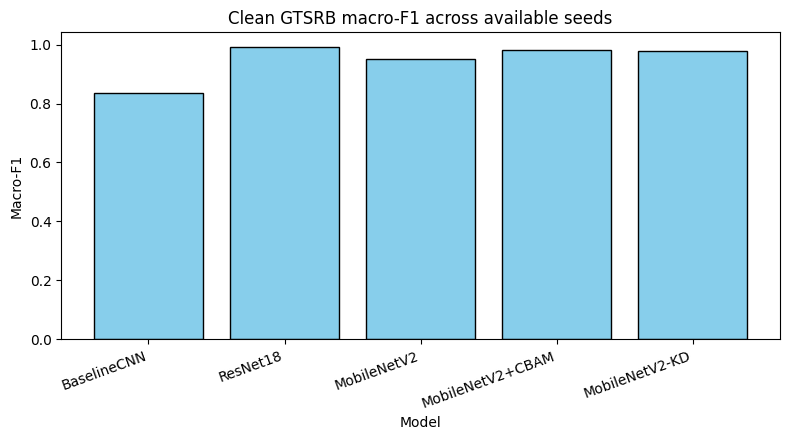

ECE                 MCE                 NLL            \
                      mean std count      mean std count      mean std count   
model                                                                          
cnn               0.083261 NaN     1  0.256688 NaN     1  0.508378 NaN     1   
mobilenetv2       0.003684 NaN     1  0.228086 NaN     1  0.143051 NaN     1   
mobilenetv2_cbam  0.005611 NaN     1  0.303633 NaN     1  0.053739 NaN     1   
mobilenetv2_kd    0.009273 NaN     1  0.316200 NaN     1  0.078775 NaN     1   
resnet18          0.004337 NaN     1  0.375767 NaN     1  0.034801 NaN     1   

                     Brier            
                      mean std count  
model                                 
cnn               0.236727 NaN     1  
mobilenetv2       0.063846 NaN     1  
mobilenetv2_cbam  0.024812 NaN     1  
mobilenetv2_kd    0.030366 NaN     1  
resnet18          0.014023 NaN     1

model      corruption severity  accuracy            macro_f1      \
                                              mean std count      mean std   
0           cnn            blur        1  0.763071 NaN     1  0.747210 NaN   
1           cnn            blur        2  0.560826 NaN     1  0.502237 NaN   
2           cnn            blur        3  0.413160 NaN     1  0.329352 NaN   
3           cnn  gaussian_noise        1  0.805407 NaN     1  0.803882 NaN   
4           cnn  gaussian_noise        2  0.711043 NaN     1  0.702393 NaN   
5           cnn  gaussian_noise        3  0.578934 NaN     1  0.552646 NaN   
6           cnn       low_light        1  0.814843 NaN     1  0.808549 NaN   
7           cnn       low_light        2  0.729661 NaN     1  0.706876 NaN   
8           cnn       low_light        3  0.528437 NaN     1  0.477709 NaN   
9           cnn       occlusion        1  0.395307 NaN     1  0.295751 NaN   
10          cnn       occlusion        2  0.261923 NaN     1  0.172577 NaN   
11          cnn       occlusion        3  0.187962 NaN     1  0.112635 NaN   
12  mobilenetv2            blur        1  0.899005 NaN     1  0.887646 NaN   
13  mobilenetv2            blur        2  0.649069 NaN     1  0.625615 NaN   
14  mobilenetv2            blur        3  0.440704 NaN     1  0.407356 NaN   
15  mobilenetv2  gaussian_noise        1  0.921959 NaN     1  0.908450 NaN   
16  mobilenetv2  gaussian_noise        2  0.842642 NaN     1  0.828466 NaN   
17  mobilenetv2  gaussian_noise        3  0.722775 NaN     1  0.705546 NaN   
18  mobilenetv2       low_light        1  0.941341 NaN     1  0.935641 NaN   
19  mobilenetv2       low_light        2  0.889569 NaN     1  0.879683 NaN   

          
   count  
0      1  
1      1  
2      1  
3      1  
4      1  
5      1  
6      1  
7      1  
8      1  
9      1  
10     1  
11     1  
12     1  
13     1  
14     1  
15     1  
16     1  
17     1  
18     1  
19     1

,model,corruption,mean,std,count
0,cnn,blur,0.329352,NaN,1
1,cnn,gaussian_noise,0.552646,NaN,1
2,cnn,low_light,0.477709,NaN,1
3,cnn,occlusion,0.112635,NaN,1
4,mobilenetv2,blur,0.407356,NaN,1
5,mobilenetv2,gaussian_noise,0.705546,NaN,1
6,mobilenetv2,low_light,0.718521,NaN,1
7,mobilenetv2,occlusion,0.033511,NaN,1
8,mobilenetv2_cbam,blur,0.398944,NaN,1
9,mobilenetv2_cbam,gaussian_noise,0.720053,NaN,1


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
model,,,,,
cnn,0.752778,0.745980,0.699557,0.697209,0.745540
mobilenetv2_cbam,0.936111,0.842018,0.866058,0.843985,0.934995
mobilenetv2_kd,0.958333,0.888594,0.903326,0.893360,0.957169
mobilenetv2,0.875000,0.800348,0.843619,0.797055,0.877885
resnet18,0.969444,0.910657,0.914526,0.905694,0.971540


,gtsdb_macro_f1,gtsrb_clean_macro_f1,domain_drop_macro_f1
model,,,
cnn,0.697209,0.835046,0.137837
mobilenetv2_cbam,0.843985,0.980413,0.136427
mobilenetv2_kd,0.893360,0.976837,0.083476
mobilenetv2,0.797055,0.949682,0.152627
resnet18,0.905694,0.991744,0.086050


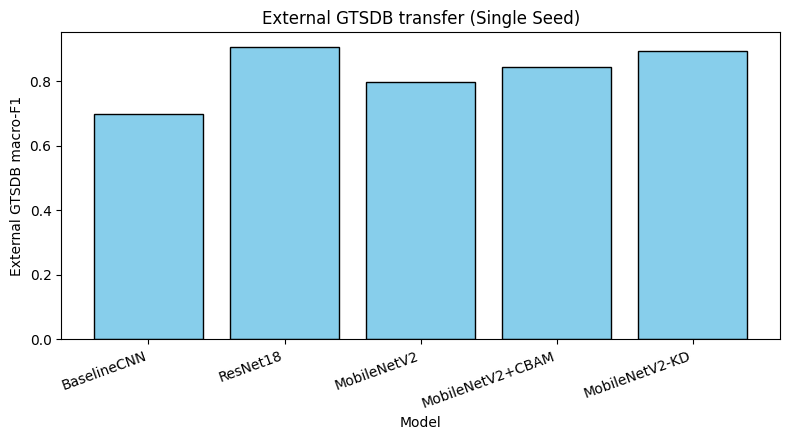

In [36]:

# ============================================================
# 17. MULTI-SEED AGGREGATION FROM ALL AVAILABLE OUTPUT FILES
# ============================================================
# This cell scans the shared output folder. It is safe to run after each seed notebook.
# Once all five notebooks have been executed/restored, the mean ± std tables and figures
# automatically summarize all available seed outputs.

import re
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

MODEL_ORDER = ["cnn", "resnet18", "mobilenetv2", "mobilenetv2_cbam", "mobilenetv2_kd"]
MODEL_LABELS = {
    "cnn": "BaselineCNN",
    "resnet18": "ResNet18",
    "mobilenetv2": "MobileNetV2",
    "mobilenetv2_cbam": "MobileNetV2+CBAM",
    "mobilenetv2_kd": "MobileNetV2-KD",
}

def _parse_model_seed_from_clean_metrics(path):
    # clean_metrics_main_resnet18_seed42.csv
    m = re.match(r"clean_metrics_main_(.+)_seed(\d+)\.csv", path.name)
    if not m:
        return None, None
    return m.group(1), int(m.group(2))

def _metric_row_from_prediction_file(path, dataset_name="gtsrb_clean"):
    dfp = pd.read_csv(path)
    y_true = dfp["true"].values
    y_pred = dfp["pred"].values
    acc = accuracy_score(y_true, y_pred)
    mp, mr, mf1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    wp, wr, wf1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return {"dataset": dataset_name, "accuracy": acc, "macro_precision": mp, "macro_recall": mr, "macro_f1": mf1, "weighted_f1": wf1, "n_samples": len(y_true)}

# 17.1 Clean metrics from individual clean metric files
clean_rows = []
for f in sorted(TABLE_DIR.glob("clean_metrics_main_*_seed*.csv")):
    model, seed = _parse_model_seed_from_clean_metrics(f)
    if model is None:
        continue
    row = pd.read_csv(f).iloc[0].to_dict()
    row["model"] = model
    row["seed"] = seed
    clean_rows.append(row)
if clean_rows:
    clean_all = pd.DataFrame(clean_rows).drop_duplicates(subset=["model", "seed"], keep="last")
    clean_all["model_label"] = clean_all["model"].map(MODEL_LABELS).fillna(clean_all["model"])
    clean_all.to_csv(TABLE_DIR / "table_clean_performance_per_seed_ALL_AVAILABLE.csv", index=False)
    clean_summary = clean_all.set_index("model")[["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]]
    clean_summary.to_csv(TABLE_DIR / "table_clean_performance_single_seed.csv")
    display(clean_all.sort_values(["model", "seed"]))
    display(clean_summary)
    plot_df = clean_all.set_index("model").reindex(MODEL_ORDER).dropna().reset_index()
    plt.figure(figsize=(8, 4.5))
    # Remove yerr completely since no variation exists within a single seed
    plt.bar(plot_df["model"].map(MODEL_LABELS), plot_df["macro_f1"], color='skyblue', edgecolor='black')
    plt.ylabel("Macro-F1")
    plt.xlabel("Model")
    plt.title("Clean GTSRB macro-F1 across available seeds")
    plt.xticks(rotation=20, ha="right")
    save_fig(FIG_DIR / "fig_clean_macro_f1_mean_std_ALL_AVAILABLE.pdf")

# 17.2 Calibration metrics recomputed from all available clean prediction files
cal_rows = []
for f in sorted(PRED_DIR.glob("predictions_clean_main_*_seed*.csv")):
    m = re.match(r"predictions_clean_main_(.+)_seed(\d+)\.csv", f.name)
    if not m:
        continue
    model, seed = m.group(1), int(m.group(2))
    dfp = pd.read_csv(f)
    prob_cols = [f"prob_{i}" for i in range(NUM_CLASSES)]
    if not all(c in dfp.columns for c in prob_cols):
        continue
    mets, _ = calibration_metrics_from_probs(dfp["true"].values, dfp[prob_cols].values, n_bins=15)
    cal_rows.append({"model": model, "seed": seed, **mets})
if cal_rows:
    cal_all = pd.DataFrame(cal_rows).drop_duplicates(subset=["model", "seed"], keep="last")
    cal_all.to_csv(TABLE_DIR / "table_calibration_metrics_per_seed_ALL_AVAILABLE.csv", index=False)
    cal_summary = cal_all.groupby("model")[["ECE", "MCE", "NLL", "Brier"]].agg(["mean", "std", "count"])
    cal_summary.to_csv(TABLE_DIR / "table_calibration_metrics_mean_std_ALL_AVAILABLE.csv")
    display(cal_summary)

# 17.3 Robustness metrics from individual corruption files
rob_rows = []
for f in sorted(TABLE_DIR.glob("robustness_main_*_seed*_*.csv")):
    try:
        row = pd.read_csv(f).iloc[0].to_dict()
        rob_rows.append(row)
    except Exception:
        pass
if rob_rows:
    rob_all = pd.DataFrame(rob_rows).drop_duplicates(subset=["model", "seed", "corruption", "severity"], keep="last")
    rob_all.to_csv(TABLE_DIR / "table_robustness_severity_per_seed_ALL_AVAILABLE.csv", index=False)
    rob_summary = rob_all.groupby(["model", "corruption", "severity"])[["accuracy", "macro_f1"]].agg(["mean", "std", "count"]).reset_index()
    rob_summary.to_csv(TABLE_DIR / "table_robustness_severity_mean_std_ALL_AVAILABLE.csv", index=False)
    display(rob_summary.head(20))
    # Main-paper compact S3 table.
    rob_s3 = rob_all[rob_all["severity"].eq(3)].copy()
    if not rob_s3.empty:
        s3_summary = rob_s3.groupby(["model", "corruption"])["macro_f1"].agg(["mean", "std", "count"]).reset_index()
        s3_summary.to_csv(TABLE_DIR / "table_robustness_s3_macro_f1_mean_std_ALL_AVAILABLE.csv", index=False)
        display(s3_summary)

# 17.4 External metrics from all available prediction files
ext_rows = []
for f in sorted(PRED_DIR.glob("predictions_external_gtsdb_*_seed*.csv")):
    m = re.match(r"predictions_external_gtsdb_(.+)_seed(\d+)\.csv", f.name)
    if not m:
        continue
    model, seed = m.group(1), int(m.group(2))
    row = _metric_row_from_prediction_file(f, dataset_name="gtsdb")
    ext_rows.append({"external_dataset": "gtsdb", "model": model, "seed": seed, **row})

if ext_rows:
    ext_all = pd.DataFrame(ext_rows).drop_duplicates(subset=["model", "seed"], keep="last")
    ext_all.to_csv(TABLE_DIR / "table_external_generalization_gtsdb_per_seed_ALL_AVAILABLE.csv", index=False)
    
    # CHANGED: Select absolute metrics directly instead of calculating aggregation means/stds
    ext_summary = ext_all.set_index("model")[["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]]
    ext_summary.to_csv(TABLE_DIR / "table_external_generalization_gtsdb_single_seed.csv")
    display(ext_summary)
    
    if 'clean_all' in globals() and not clean_all.empty:
        drop_rows = []
        for _, r in ext_all.iterrows():
            hit = clean_all[(clean_all["model"].eq(r["model"])) & (clean_all["seed"].eq(r["seed"]))]
            if not hit.empty:
                clean_f1 = float(hit["macro_f1"].iloc[0])
                drop_rows.append({
                    "model": r["model"], 
                    "seed": r["seed"], 
                    "gtsdb_macro_f1": r["macro_f1"], 
                    "gtsrb_clean_macro_f1": clean_f1, 
                    "domain_drop_macro_f1": clean_f1 - float(r["macro_f1"])
                })
        if drop_rows:
            drop_df = pd.DataFrame(drop_rows)
            drop_df.to_csv(TABLE_DIR / "table_external_domain_drop_gtsdb_single_seed.csv", index=False)
            
            # CHANGED: Replaced the groupby aggregation with a simple index display to prevent NaN output
            display(drop_df.set_index("model")[["gtsdb_macro_f1", "gtsrb_clean_macro_f1", "domain_drop_macro_f1"]])
            
    # CHANGED: Fetch the exact macro_f1 rows without a multi-seed grouping loop
    plot_df = ext_all.set_index("model").reindex(MODEL_ORDER).dropna().reset_index()
    
    plt.figure(figsize=(8, 4.5))
    # CHANGED: Removed 'yerr' parameter and 'plot_df["mean"]' to plot absolute single-run metrics cleanly
    plt.bar(plot_df["model"].map(MODEL_LABELS), plot_df["macro_f1"], color='skyblue', edgecolor='black')
    
    plt.ylabel("External GTSDB macro-F1")
    plt.xlabel("Model")
    plt.title("External GTSDB transfer (Single Seed)")
    plt.xticks(rotation=20, ha="right")
    
    # SAVING: Adjusted the filename destination to reflect a single-seed architecture plot
    save_fig(FIG_DIR / "fig_external_gtsdb_macro_f1_single_seed.pdf")


In [1]:

# ============================================================
# 16. ZIP OUTPUTS FOR DOWNLOAD OR KAGGLE DATASET VERSIONING
# ============================================================

if any(stage in ["package", "all"] for stage in RUN_STAGE):
    zip_path = "/kaggle/working/revision_outputs_fast128.zip"
    if OUT_DIR.exists():
        !zip -r -q {zip_path} {OUT_DIR}
        print("Created:", zip_path)
    else:
        print("Output directory not found:", OUT_DIR)


NameError: name 'RUN_STAGE' is not defined